**AI/ML Internship — Week 3**                                    
**Visualization Dashboard & Feature Engineering Pipeline**                                          
**Dataset:** House Prices — Advanced Regression Techniques                                      
**Student Name**: [Usman Asif]                                                   
**Date**: [26 april,26]

**PART A —  MATPLOTLIB MASTERY**

**Step 1 — Environment Setup & Dataset Loading**

In [1]:
# ==============================================
# IMPORT LIBRARIES
# ==============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew
from scipy.stats import boxcox

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

from sklearn.feature_selection import VarianceThreshold

import warnings
warnings.filterwarnings('ignore')

# ==============================================
# PROFESSIONAL VISUAL STYLE
# ==============================================

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

sns.set_style('whitegrid')

# ==============================================
# LOAD DATASET
# ==============================================

df = pd.read_csv('train.csv')

print('Dataset Shape:', df.shape)

print('\n================ DATASET INFO ================')
print(df.info())

print('\n================ DESCRIPTIVE STATISTICS ================')
print(df.describe())

# ==============================================
# IDENTIFY NUMERICAL & CATEGORICAL COLUMNS
# ==============================================

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

print('\nNumber of Numerical Columns:', len(num_cols))
print('Number of Categorical Columns:', len(cat_cols))

print('\nNumerical Columns:')
print(num_cols)

print('\nCategorical Columns:')
print(cat_cols)

# ==============================================
# TOP CORRELATED FEATURES WITH SalePrice
# ==============================================

corr_with_target = (
    df.corr(numeric_only=True)['SalePrice']
    .abs()
    .sort_values(ascending=False)
)

print('\nTop 10 Features Correlated With SalePrice:')
print(corr_with_target.head(10))

Dataset Shape: (1460, 81)

================ DATASET INFO ================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 no

**Step 2 — Matplotlib Chart 1 & 2 — Distribution Analysis**

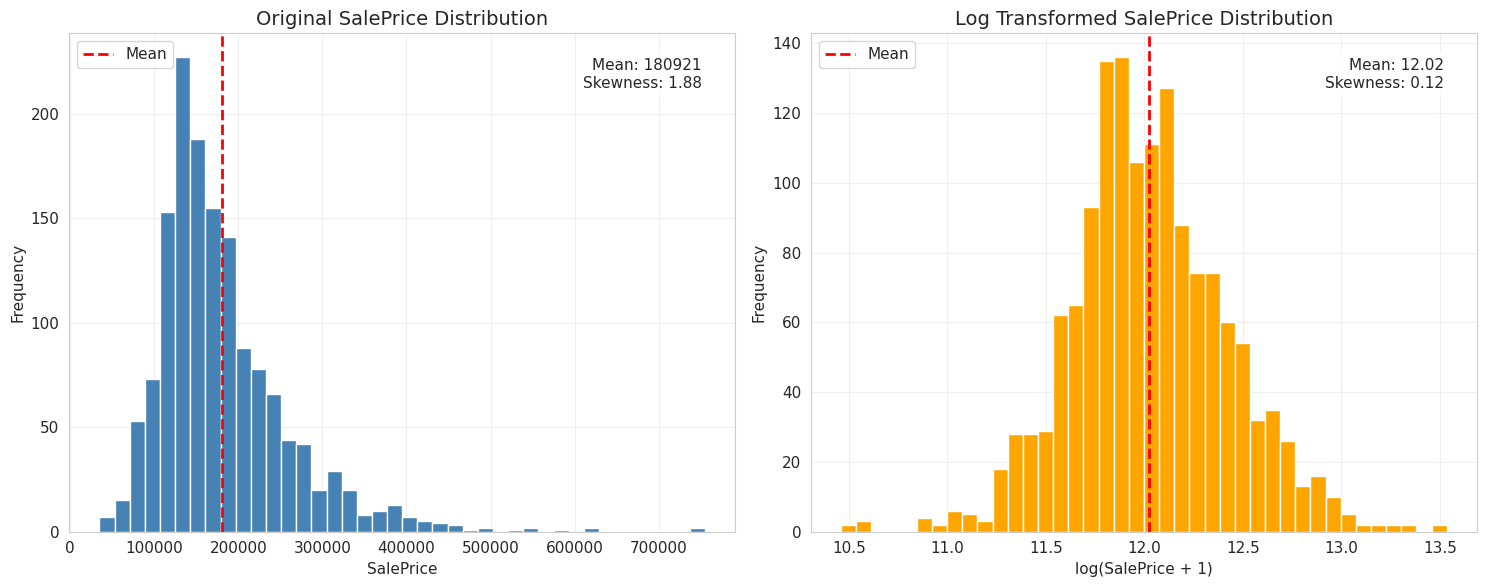

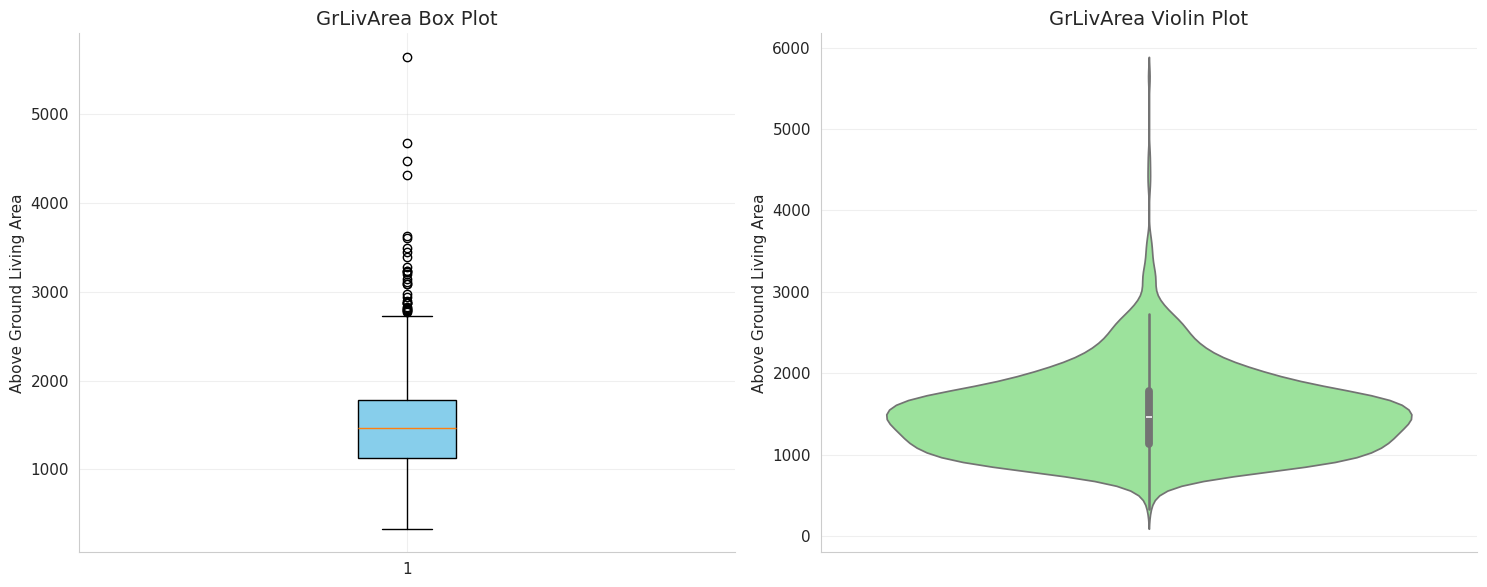

In [2]:
# ==============================================
# CHART 1 — SalePrice Distribution
# ==============================================

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# ----------------------------------------------
# Original SalePrice Distribution
# ----------------------------------------------

ax[0].hist(
    df['SalePrice'],
    bins=40,
    color='steelblue',
    edgecolor='white'
)

mean_price = df['SalePrice'].mean()
skew_price = df['SalePrice'].skew()

ax[0].axvline(
    mean_price,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Mean'
)

ax[0].set_title('Original SalePrice Distribution')
ax[0].set_xlabel('SalePrice')
ax[0].set_ylabel('Frequency')
ax[0].legend()

ax[0].text(
    0.95,
    0.95,
    f'Mean: {mean_price:.0f}\nSkewness: {skew_price:.2f}',
    transform=ax[0].transAxes,
    ha='right',
    va='top',
    bbox=dict(facecolor='white', alpha=0.8)
)

# ----------------------------------------------
# Log Transformed SalePrice Distribution
# ----------------------------------------------

log_price = np.log1p(df['SalePrice'])

ax[1].hist(
    log_price,
    bins=40,
    color='orange',
    edgecolor='white'
)

log_mean = log_price.mean()
log_skew = log_price.skew()

ax[1].axvline(
    log_mean,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Mean'
)

ax[1].set_title('Log Transformed SalePrice Distribution')
ax[1].set_xlabel('log(SalePrice + 1)')
ax[1].set_ylabel('Frequency')
ax[1].legend()

ax[1].text(
    0.95,
    0.95,
    f'Mean: {log_mean:.2f}\nSkewness: {log_skew:.2f}',
    transform=ax[1].transAxes,
    ha='right',
    va='top',
    bbox=dict(facecolor='white', alpha=0.8)
)

plt.tight_layout()

# Save Figure
plt.savefig(
    'w3_saleprice_distribution.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ==============================================
# CHART 2 — GrLivArea Distribution
# ==============================================

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# ----------------------------------------------
# Box Plot
# ----------------------------------------------

ax[0].boxplot(
    df['GrLivArea'],
    patch_artist=True,
    boxprops=dict(facecolor='skyblue')
)

ax[0].set_title('GrLivArea Box Plot')
ax[0].set_ylabel('Above Ground Living Area')

# ----------------------------------------------
# Violin Plot
# ----------------------------------------------

sns.violinplot(
    y=df['GrLivArea'],
    ax=ax[1],
    color='lightgreen'
)

ax[1].set_title('GrLivArea Violin Plot')
ax[1].set_ylabel('Above Ground Living Area')

# ----------------------------------------------
# Spine Cleanup
# ----------------------------------------------

for axis in ax:
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)

plt.tight_layout()

# Save Figure
plt.savefig(
    'w3_grlivarea_distribution.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

**Step 3 — Matplotlib Chart 3 — Multi-Variable Scatter Plot**

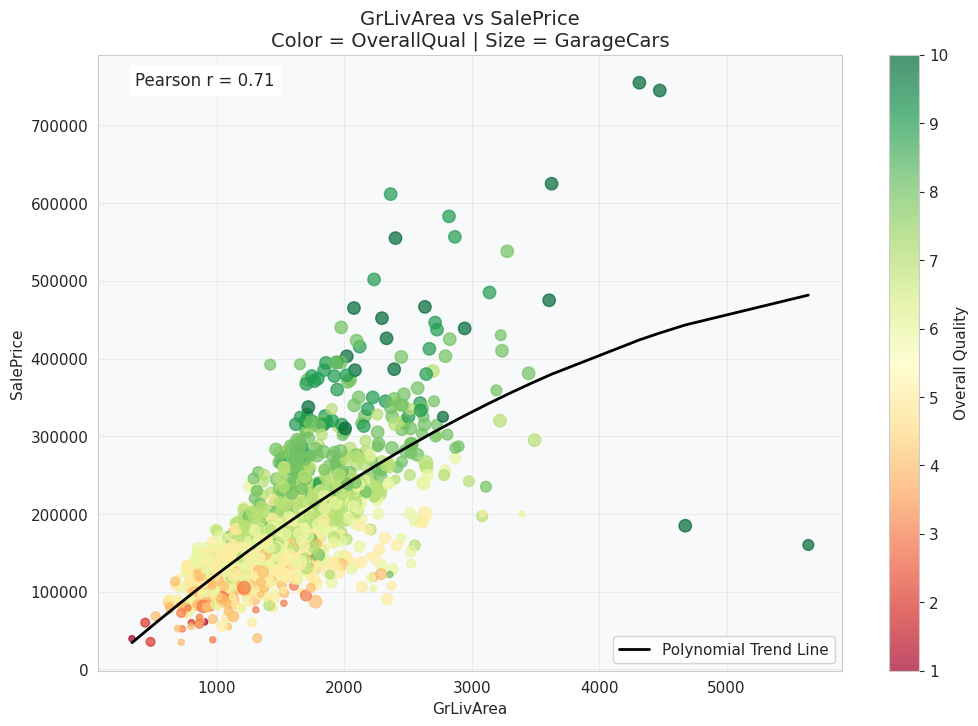

In [3]:
# ==============================================
# MULTI-VARIABLE SCATTER PLOT
# ==============================================

plt.figure(figsize=(12, 8))

# Scatter Plot
scatter = plt.scatter(
    df['GrLivArea'],
    df['SalePrice'],
    c=df['OverallQual'],
    s=df['GarageCars'] * 20 + 20,
    cmap=plt.cm.RdYlGn,
    alpha=0.7
)

# ----------------------------------------------
# Set Facecolor
# ----------------------------------------------

ax = plt.gca()
ax.set_facecolor('#f8f9fa')

# ----------------------------------------------
# Polynomial Regression Line (Degree = 2)
# ----------------------------------------------

z = np.polyfit(
    df['GrLivArea'],
    df['SalePrice'],
    2
)

p = np.poly1d(z)

x_sorted = np.sort(df['GrLivArea'])

plt.plot(
    x_sorted,
    p(x_sorted),
    color='black',
    linewidth=2,
    label='Polynomial Trend Line'
)

# ----------------------------------------------
# Pearson Correlation
# ----------------------------------------------

corr = df['GrLivArea'].corr(df['SalePrice'])

plt.annotate(
    f'Pearson r = {corr:.2f}',
    xy=(0.05, 0.95),
    xycoords='axes fraction',
    fontsize=12,
    bbox=dict(facecolor='white')
)

# ----------------------------------------------
# Colorbar
# ----------------------------------------------

cbar = plt.colorbar(scatter)
cbar.set_label('Overall Quality')

# ----------------------------------------------
# Labels & Title
# ----------------------------------------------

plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')

plt.title(
    'GrLivArea vs SalePrice\n'
    'Color = OverallQual | Size = GarageCars'
)

plt.legend()

# Save Figure
plt.savefig(
    'w3_multivariable_scatter.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

**Step 4 — Matplotlib Chart 4 — Time-Based Trend Analysis**

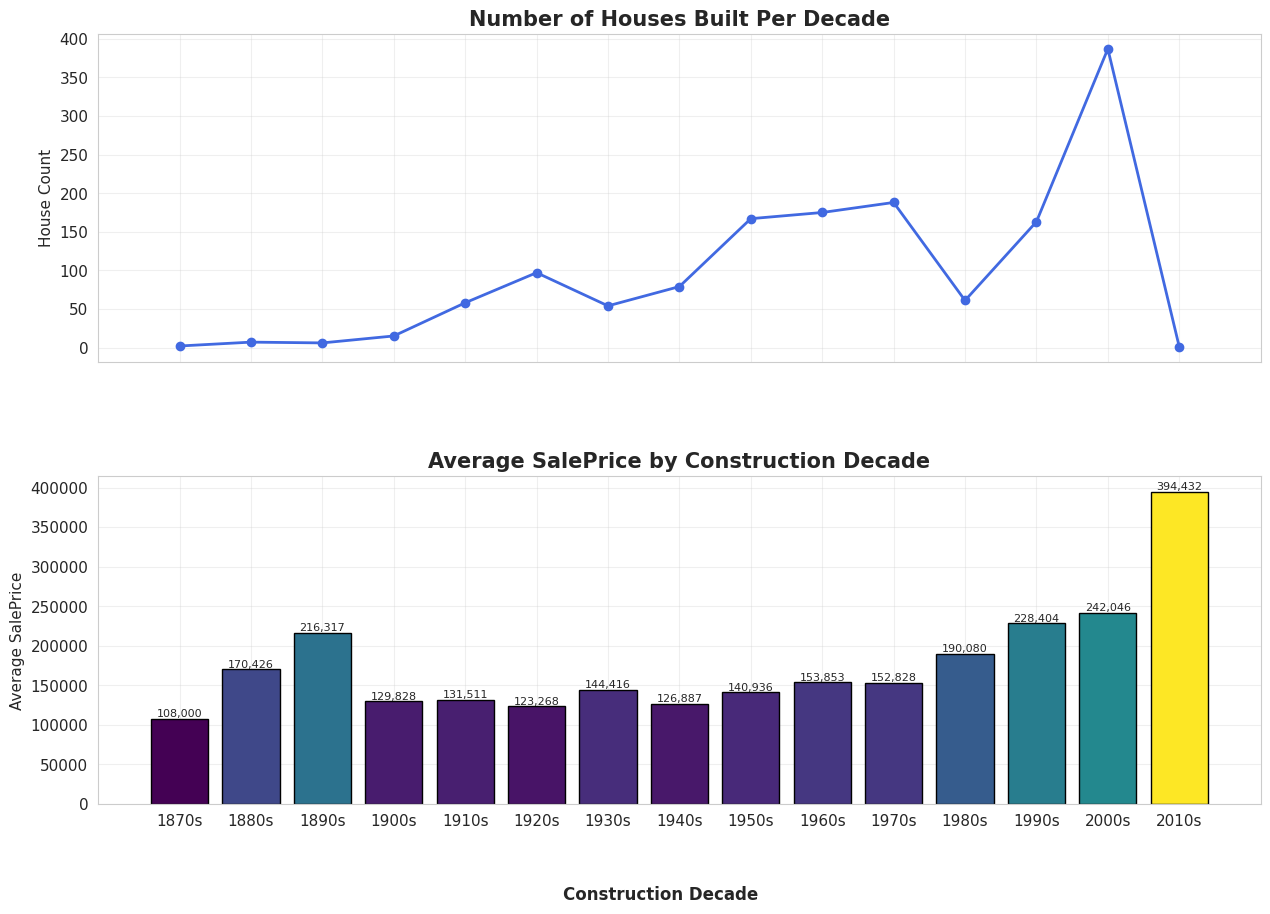

In [4]:
# ==============================================
# STEP 4 — TIME-BASED TREND ANALYSIS
# ==============================================

# Create Decade Column
df['Decade'] = (df['YearBuilt'] // 10) * 10

# Convert to decade labels
df['DecadeLabel'] = df['Decade'].astype(str) + 's'

# Houses Count Per Decade
houses_per_decade = (
    df['DecadeLabel']
    .value_counts()
    .sort_index()
)

# Average Price Per Decade
avg_price_decade = (
    df.groupby('DecadeLabel')['SalePrice']
    .mean()
)

# ==============================================
# CREATE FIGURE
# ==============================================

fig, ax = plt.subplots(
    2,
    1,
    figsize=(15, 10),
    sharex=True
)

# ==============================================
# TOP PLOT — LINE CHART
# ==============================================

ax[0].plot(
    houses_per_decade.index,
    houses_per_decade.values,
    marker='o',
    linewidth=2,
    color='royalblue'
)

ax[0].set_title(
    'Number of Houses Built Per Decade',
    fontsize=15,
    fontweight='bold'
)

ax[0].set_ylabel('House Count')

ax[0].grid(alpha=0.3)

# ==============================================
# BOTTOM PLOT — BAR CHART
# ==============================================

# Normalize colors
norm = plt.Normalize(
    avg_price_decade.min(),
    avg_price_decade.max()
)

# Gradient colors
colors = plt.cm.viridis(
    norm(avg_price_decade.values)
)

bars = ax[1].bar(
    avg_price_decade.index,
    avg_price_decade.values,
    color=colors,
    edgecolor='black'
)

ax[1].set_title(
    'Average SalePrice by Construction Decade',
    fontsize=15,
    fontweight='bold'
)

ax[1].set_ylabel('Average SalePrice')

# ==============================================
# VALUE LABELS
# ==============================================

for bar in bars:

    height = bar.get_height()

    ax[1].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

# ==============================================
# SHARED X LABEL
# ==============================================

fig.supxlabel(
    'Construction Decade',
    fontsize=12,
    fontweight='bold'
)

# ==============================================
# SPACING
# ==============================================

plt.subplots_adjust(hspace=0.35)

# ==============================================
# SAVE FIGURE
# ==============================================

plt.savefig(
    'w3_time_trend.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

**Step 5 — Seaborn Charts 5 & 6 — Statistical Visualization**

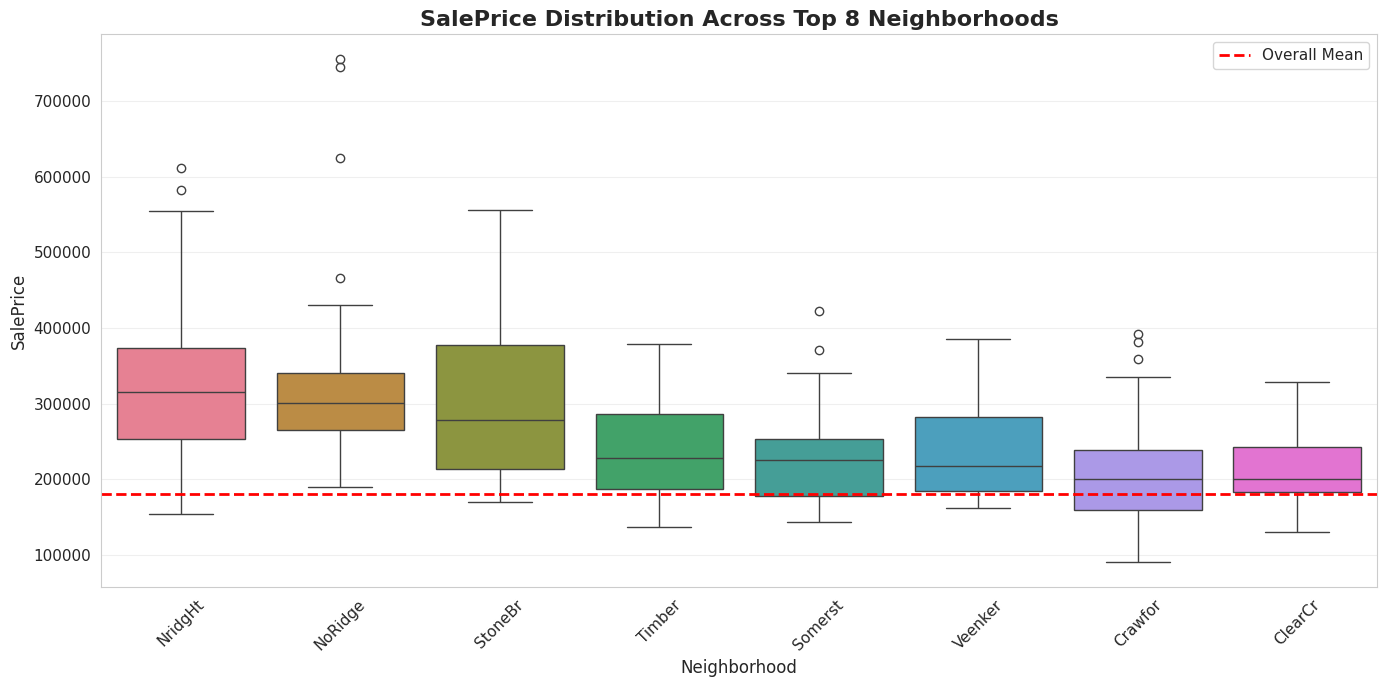

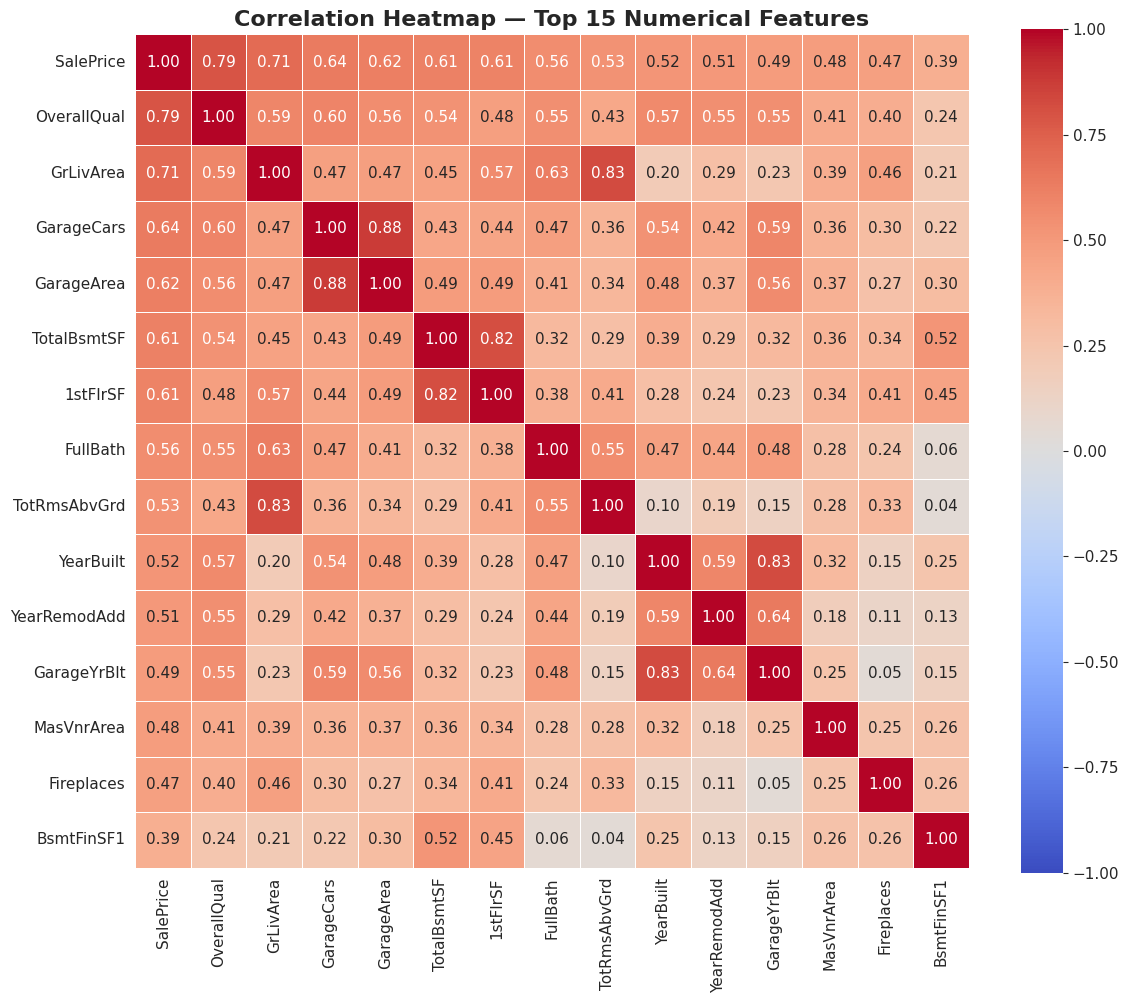

In [5]:
# ==============================================
# IMPORT LIBRARIES
# ==============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================
# PROFESSIONAL STYLE
# ==============================================

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

sns.set_style('whitegrid')

# ==============================================
# LOAD DATASET
# ==============================================

df = pd.read_csv('train.csv')

# ==============================================
# CHART 5 — BOXPLOT
# SalePrice Distribution Across Top 8 Neighborhoods
# ==============================================

# Find Top 8 Neighborhoods by Median SalePrice
top_neighborhoods = (
    df.groupby('Neighborhood')['SalePrice']
    .median()
    .sort_values(ascending=False)
    .head(8)
)

# Filter Dataset
filtered_df = df[
    df['Neighborhood'].isin(top_neighborhoods.index)
]

# ==============================================
# CREATE FIGURE
# ==============================================

plt.figure(figsize=(14, 7))

# Create Boxplot
ax = sns.boxplot(
    x='Neighborhood',
    y='SalePrice',
    data=filtered_df,
    order=top_neighborhoods.index,
    palette='husl'
)

# Add Horizontal Mean Line
ax.axhline(
    df['SalePrice'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label='Overall Mean'
)

# ==============================================
# STYLING
# ==============================================

plt.title(
    'SalePrice Distribution Across Top 8 Neighborhoods',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    'Neighborhood',
    fontsize=12
)

plt.ylabel(
    'SalePrice',
    fontsize=12
)

# Rotate Labels
plt.xticks(rotation=45)

# Legend
plt.legend()

# Layout
plt.tight_layout()

# Save Figure
plt.savefig(
    'w3_neighborhood_boxplot.png',
    dpi=150,
    bbox_inches='tight'
)

# Show Plot
plt.show()

# ==============================================
# CHART 6 — CORRELATION HEATMAP
# ==============================================

# Select Top 15 Numerical Features
top15_features = (
    df.corr(numeric_only=True)['SalePrice']
    .abs()
    .sort_values(ascending=False)
    .head(15)
    .index
)

# Correlation Matrix
corr_matrix = df[top15_features].corr()

# ==============================================
# CREATE FIGURE
# ==============================================

plt.figure(figsize=(12, 10))

# Create Heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

# ==============================================
# STYLING
# ==============================================

plt.title(
    'Correlation Heatmap — Top 15 Numerical Features',
    fontsize=16,
    fontweight='bold'
)

# Layout
plt.tight_layout()

# Save Figure
plt.savefig(
    'w3_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

# Show Plot
plt.show()

**Step 6 — Seaborn Advanced — FacetGrid & Pair Plot**

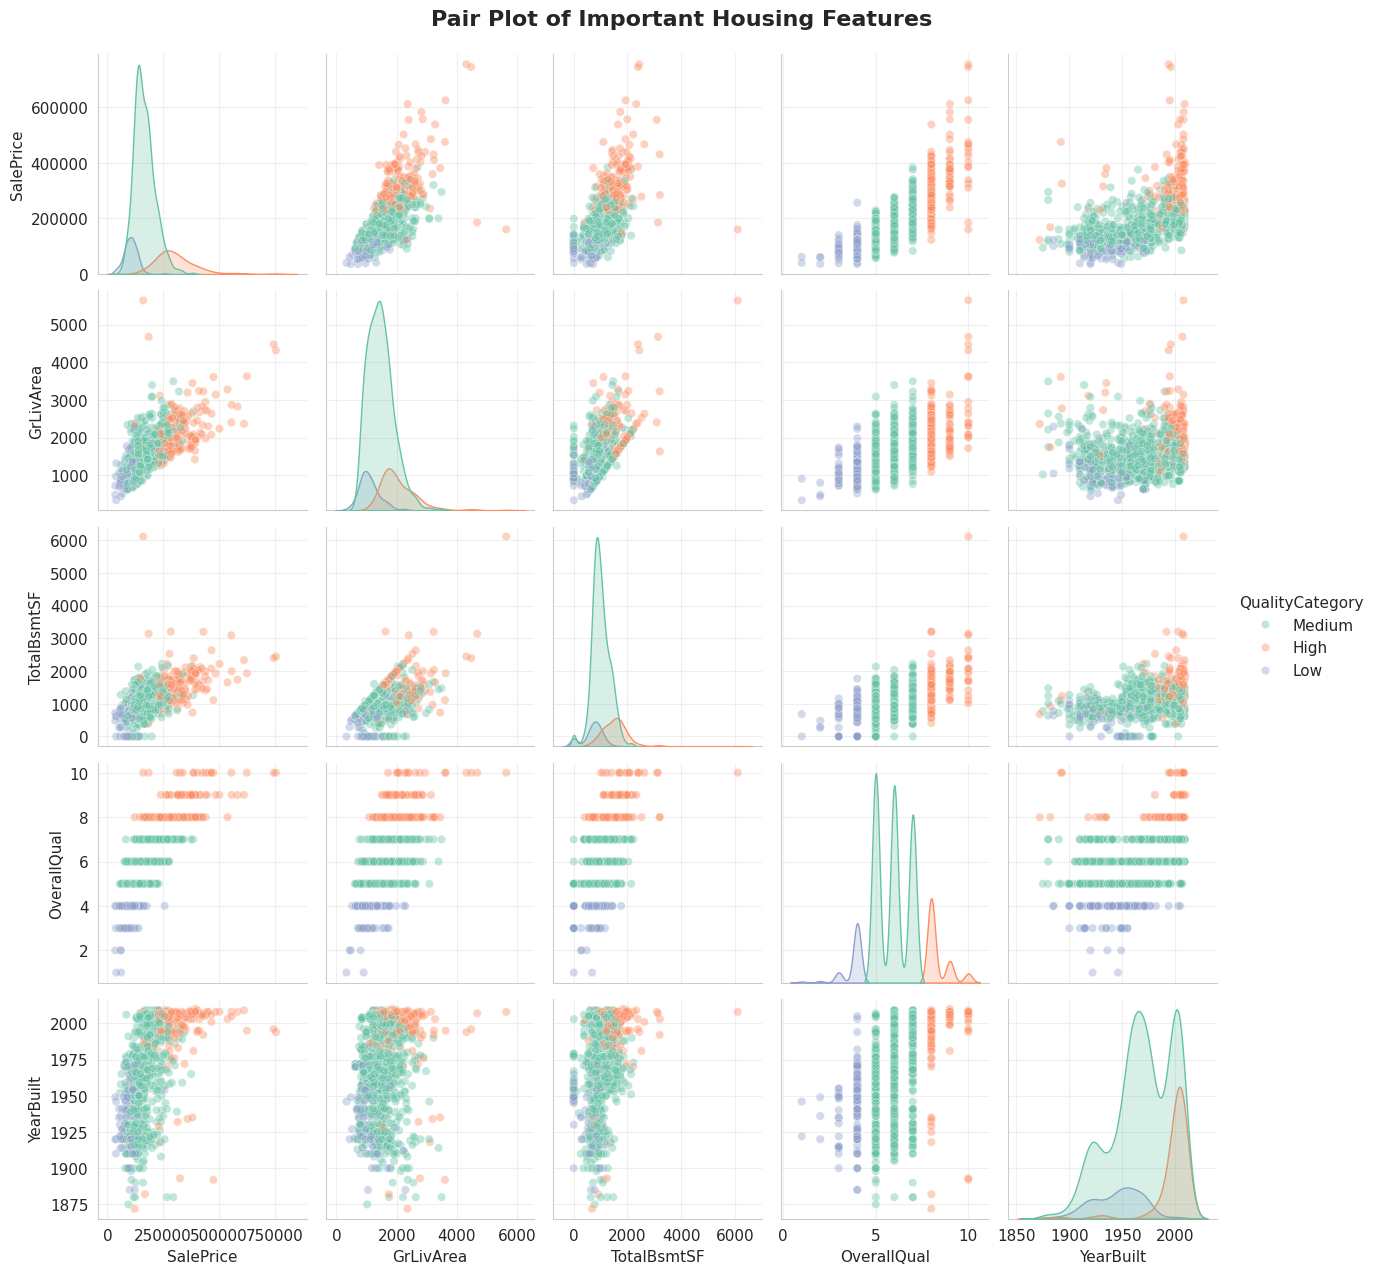

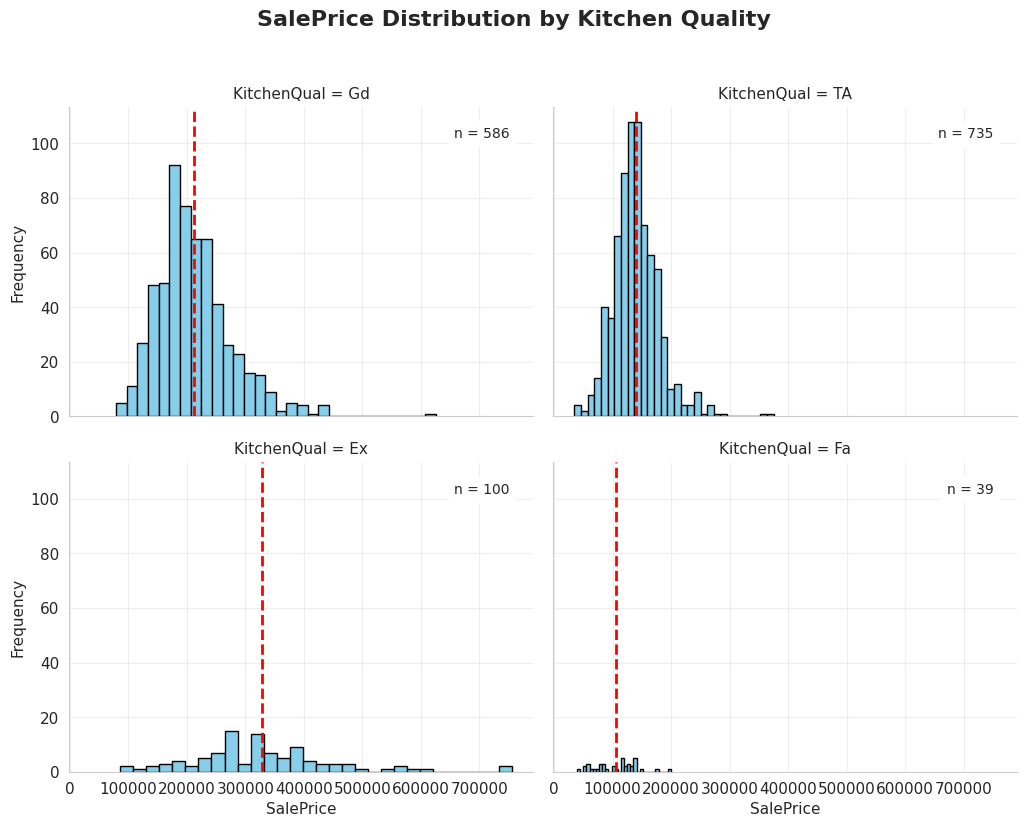

In [6]:
# ==============================================
# IMPORT LIBRARIES
# ==============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================
# PROFESSIONAL STYLE
# ==============================================

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

sns.set_style('whitegrid')

# ==============================================
# LOAD DATASET
# ==============================================

df = pd.read_csv('train.csv')

# ==============================================
# CHART 7 — PAIRPLOT
# ==============================================

# Selected Columns
pair_cols = [
    'SalePrice',
    'GrLivArea',
    'TotalBsmtSF',
    'OverallQual',
    'YearBuilt'
]

# ==============================================
# CREATE QUALITY CATEGORY
# ==============================================

def quality_bin(x):

    if x <= 4:
        return 'Low'

    elif x <= 7:
        return 'Medium'

    else:
        return 'High'

# Apply Category Binning
df['QualityCategory'] = (
    df['OverallQual']
    .apply(quality_bin)
)

# ==============================================
# CREATE PAIRPLOT
# ==============================================

pair_plot = sns.pairplot(
    df[pair_cols + ['QualityCategory']],
    hue='QualityCategory',
    diag_kind='kde',
    palette='Set2',
    plot_kws={'alpha':0.4}
)

# ==============================================
# TITLE
# ==============================================

pair_plot.fig.suptitle(
    'Pair Plot of Important Housing Features',
    y=1.02,
    fontsize=16,
    fontweight='bold'
)

# Save Figure
plt.savefig(
    'w3_pairplot.png',
    dpi=150,
    bbox_inches='tight'
)

# Show Plot
plt.show()

# ==============================================
# CHART 8 — FACETGRID
# ==============================================

# Create FacetGrid
g = sns.FacetGrid(
    df,
    col='KitchenQual',
    col_wrap=2,
    height=4,
    aspect=1.3
)

# Create Histograms
g.map(
    plt.hist,
    'SalePrice',
    bins=30,
    color='skyblue',
    edgecolor='black'
)

# ==============================================
# ADD MEAN LINES & COUNT ANNOTATIONS
# ==============================================

for ax, quality in zip(g.axes.flat, df['KitchenQual'].unique()):

    # Filter Data
    subset = df[
        df['KitchenQual'] == quality
    ]

    # Mean Price
    mean_price = subset['SalePrice'].mean()

    # Count
    count = subset.shape[0]

    # Mean Line
    ax.axvline(
        mean_price,
        color='red',
        linestyle='--',
        linewidth=2
    )

    # Count Annotation
    ax.text(
        0.95,
        0.90,
        f'n = {count}',
        transform=ax.transAxes,
        ha='right',
        fontsize=10,
        bbox=dict(facecolor='white')
    )

    # Axis Labels
    ax.set_xlabel('SalePrice')
    ax.set_ylabel('Frequency')

# ==============================================
# TITLE
# ==============================================

g.fig.suptitle(
    'SalePrice Distribution by Kitchen Quality',
    y=1.03,
    fontsize=16,
    fontweight='bold'
)

# Layout
plt.tight_layout()

# Save Figure
plt.savefig(
    'w3_facetgrid.png',
    dpi=150,
    bbox_inches='tight'
)

# Show Plot
plt.show()

**PART B — FEATURE ENGINEERING**

**Step 7 — Feature Creation — 8 Engineered Features**

In [7]:
# ==============================================
# HANDLE MISSING VALUES
# ==============================================

# Fill missing numerical values with median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill missing categorical values with 'NA'
for col in cat_cols:
    df[col].fillna('NA', inplace=True)

# ==============================================
# FEATURE ENGINEERING
# ==============================================

# (a) TotalSF combines basement and all floor areas to represent total usable property space.
df['TotalSF'] = (
    df['TotalBsmtSF'] +
    df['1stFlrSF'] +
    df['2ndFlrSF']
)

# (b) TotalBaths creates a weighted bathroom count using full and half bathrooms.
df['TotalBaths'] = (
    df['FullBath'] +
    0.5 * df['HalfBath'] +
    df['BsmtFullBath'] +
    0.5 * df['BsmtHalfBath']
)

# (c) HouseAge measures how old the property was at the time of sale.
df['HouseAge'] = (
    df['YrSold'] - df['YearBuilt']
)

# (d) RemodelAge calculates years since the last remodeling.
df['RemodelAge'] = (
    df['YrSold'] - df['YearRemodAdd']
)

# (e) HasRemodeled identifies whether the house has ever been remodeled.
df['HasRemodeled'] = (
    df['YearBuilt'] != df['YearRemodAdd']
).astype(int)

# (f) QualCond combines overall quality and condition into one interaction feature.
df['QualCond'] = (
    df['OverallQual'] * df['OverallCond']
)

# (g) PricePerSF measures property price density per square foot.
df['PricePerSF'] = np.where(
    df['TotalSF'] > 0,
    df['SalePrice'] / df['TotalSF'],
    0
)

# (h) IsNewHouse identifies houses built within the last 5 years before sale.
df['IsNewHouse'] = (
    df['YearBuilt'] >= (df['YrSold'] - 5)
).astype(int)

# ==============================================
# STORE FEATURE NAMES
# ==============================================

new_features = [
    'TotalSF',
    'TotalBaths',
    'HouseAge',
    'RemodelAge',
    'HasRemodeled',
    'QualCond',
    'PricePerSF',
    'IsNewHouse'
]

# ==============================================
# DISPLAY RESULTS
# ==============================================

print("=========== ENGINEERED FEATURES SUMMARY ===========")
print(df[new_features].describe())

print("\n=========== FIRST 10 ROWS ===========")
print(df[new_features].head(10))

=========== ENGINEERED FEATURES SUMMARY ===========
            TotalSF   TotalBaths     HouseAge   RemodelAge  HasRemodeled  \
count   1460.000000  1460.000000  1460.000000  1460.000000   1460.000000   
mean    2567.048630     2.210616    36.547945    22.950000      0.476712   
std      821.714421     0.785399    30.250152    20.640653      0.499629   
min      334.000000     1.000000     0.000000    -1.000000      0.000000   
25%     2009.500000     2.000000     8.000000     4.000000      0.000000   
50%     2474.000000     2.000000    35.000000    14.000000      0.000000   
75%     3004.000000     2.500000    54.000000    41.000000      1.000000   
max    11752.000000     6.000000   136.000000    60.000000      1.000000   

          QualCond   PricePerSF   IsNewHouse  
count  1460.000000  1460.000000  1460.000000  
mean     33.864384    69.944000     0.212329  
std       9.219624    15.397065     0.409096  
min       1.000000    13.614704     0.000000  
25%      30.000000    60.461

**Step 8 — Correlation Analysis of Engineered Features**


=========== TOP 20 CORRELATIONS ===========
SalePrice       1.000000
OverallQual     0.790982
TotalSF         0.782260
GrLivArea       0.708624
PricePerSF      0.640602
GarageCars      0.640409
TotalBaths      0.631731
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
QualCond        0.565294
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
GarageYrBlt     0.466754
IsNewHouse      0.433543
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

=========== BOTTOM 10 CORRELATIONS ===========
Id              -0.021917
HasRemodeled    -0.021933
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
RemodelAge      -0.509079
HouseAge        -0.523350
Name: SalePrice, dtype: float64


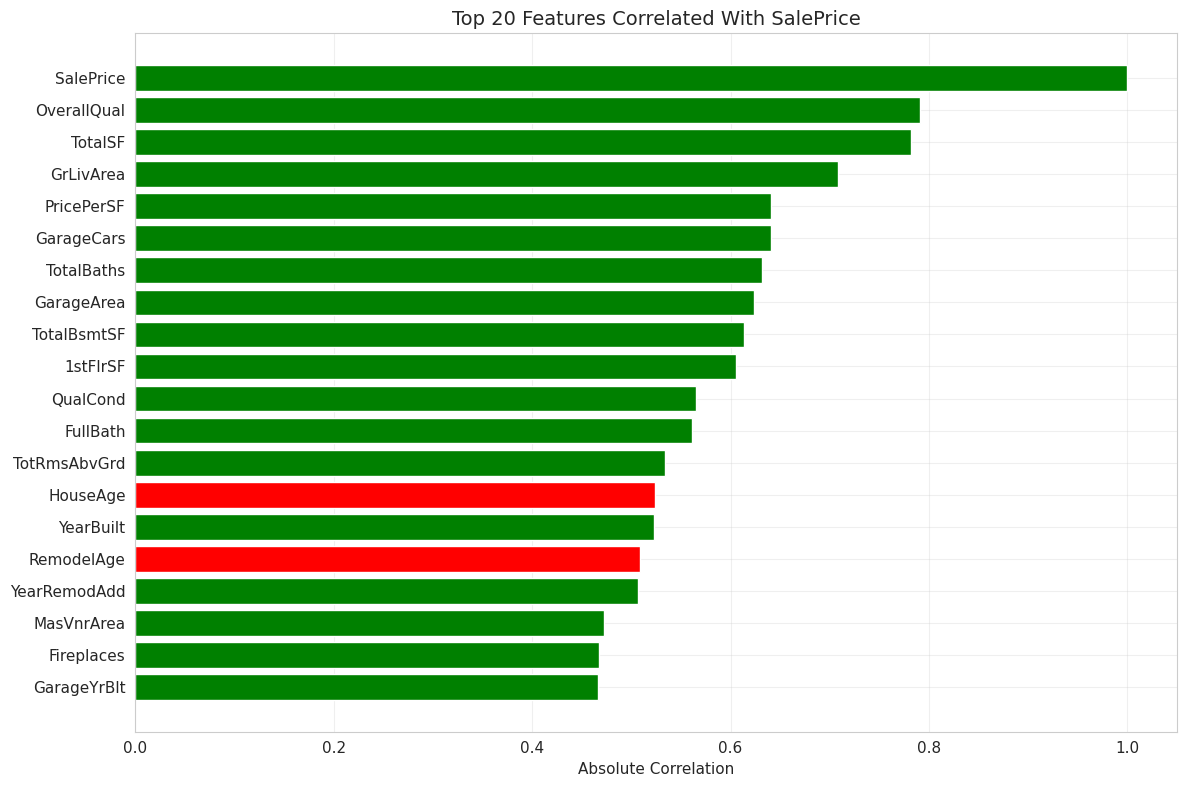

In [8]:
# ==============================================
# CORRELATION ANALYSIS
# ==============================================

corr_all = (
    df.corr(numeric_only=True)['SalePrice']
    .sort_values(ascending=False)
)

# ==============================================
# TOP 20 FEATURES
# ==============================================

print("\n=========== TOP 20 CORRELATIONS ===========")
print(corr_all.head(20))

# ==============================================
# BOTTOM 10 FEATURES
# ==============================================

print("\n=========== BOTTOM 10 CORRELATIONS ===========")
print(corr_all.tail(10))

# ==============================================
# HORIZONTAL BAR CHART
# ==============================================

top20 = corr_all.abs().sort_values(
    ascending=False
).head(20)

# Green for positive, Red for negative
colors = [
    'green' if corr_all[col] > 0 else 'red'
    for col in top20.index
]

plt.figure(figsize=(12, 8))

plt.barh(
    top20.index,
    top20.values,
    color=colors
)

plt.xlabel('Absolute Correlation')
plt.title('Top 20 Features Correlated With SalePrice')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Analysis of Engineered Features

Several engineered features successfully entered the top 20 correlated features with SalePrice, especially:

- TotalSF
- TotalBaths
- QualCond
- PricePerSF

This demonstrates the importance of feature engineering because combining raw variables often reveals stronger relationships with the target variable than original features alone. Engineered features help machine learning models better capture hidden patterns and improve predictive performance.

**Step 9 — Categorical Variable Analysis & Encoding Strategy**

In [9]:
# ==============================================
# IDENTIFY CATEGORICAL COLUMNS
# ==============================================

categorical_columns = df.select_dtypes(
    include='object'
).columns

encoding_strategy = {}

# ==============================================
# ANALYZE EACH CATEGORICAL COLUMN
# ==============================================

for col in categorical_columns:

    print("\n====================================")
    print(f"COLUMN: {col}")
    print("====================================")

    # ------------------------------------------
    # Number of unique categories
    # ------------------------------------------

    unique_count = df[col].nunique()

    print("\nUnique Categories:")
    print(unique_count)

    # ------------------------------------------
    # Value counts
    # ------------------------------------------

    print("\nValue Counts:")
    print(df[col].value_counts())

    # ------------------------------------------
    # Mean SalePrice per category
    # ------------------------------------------

    print("\nMean SalePrice Per Category:")

    mean_prices = (
        df.groupby(col)['SalePrice']
        .mean()
        .sort_values(ascending=False)
    )

    print(mean_prices)

    # ------------------------------------------
    # Missing percentage
    # ------------------------------------------

    missing_percent = (
        df[col].isnull().mean()
    )

    # ------------------------------------------
    # Dominant category percentage
    # ------------------------------------------

    dominant_percent = (
        df[col]
        .value_counts(normalize=True)
        .max()
    )

    # ==========================================
    # ENCODING STRATEGY CLASSIFICATION
    # ==========================================

    if (
        missing_percent > 0.50 or
        dominant_percent > 0.95
    ):

        strategy = 'drop'

    elif col in [
        'ExterQual',
        'KitchenQual',
        'BsmtQual',
        'GarageQual',
        'FireplaceQu'
    ]:

        strategy = 'label_encode'

    elif unique_count <= 10:

        strategy = 'onehot_encode'

    else:

        strategy = 'frequency_encode'

    encoding_strategy[col] = strategy

    print("\nEncoding Strategy:")
    print(strategy)


COLUMN: MSZoning

Unique Categories:
5

Value Counts:
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

Mean SalePrice Per Category:
MSZoning
FV         214014.061538
RL         191004.994787
RH         131558.375000
RM         126316.830275
C (all)     74528.000000
Name: SalePrice, dtype: float64

Encoding Strategy:
onehot_encode

COLUMN: Street

Unique Categories:
2

Value Counts:
Street
Pave    1454
Grvl       6
Name: count, dtype: int64

Mean SalePrice Per Category:
Street
Pave    181130.538514
Grvl    130190.500000
Name: SalePrice, dtype: float64

Encoding Strategy:
drop

COLUMN: Alley

Unique Categories:
3

Value Counts:
Alley
NA      1369
Grvl      50
Pave      41
Name: count, dtype: int64

Mean SalePrice Per Category:
Alley
NA      183452.131483
Pave    168000.585366
Grvl    122219.080000
Name: SalePrice, dtype: float64

Encoding Strategy:
onehot_encode

COLUMN: LotShape

Unique Categories:
4

Value Counts:
LotS

# Encoding Decision Table

| Encoding Type | Description | Example Columns | Reason |
|---|---|---|---|
| Label Encoding | Used for ordinal quality features | KitchenQual, ExterQual, BsmtQual | Categories have natural ranking |
| One-Hot Encoding | Used for low-cardinality nominal features | MSZoning, SaleCondition | Prevents false ordering |
| Frequency Encoding | Used for high-cardinality nominal features | Neighborhood | Reduces dimensionality |
| Drop | Used for columns with excessive missing values or dominant category | Alley, PoolQC | Low predictive value |

**Step 10 — Apply All Encoding Strategies**

In [10]:
# ==============================================
# SHAPE BEFORE ENCODING
# ==============================================

print("Shape Before Encoding:", df.shape)

# ==============================================
# LABEL ENCODING
# ==============================================

quality_map = {
    'Ex': 5,
    'Gd': 4,
    'TA': 3,
    'Fa': 2,
    'Po': 1,
    'NA': 0
}

quality_cols = [
    'ExterQual',
    'KitchenQual',
    'BsmtQual',
    'GarageQual',
    'FireplaceQu'
]

for col in quality_cols:

    if col in df.columns:

        df[col] = (
            df[col]
            .fillna('NA')
            .map(quality_map)
        )

# ==============================================
# FREQUENCY ENCODING
# ==============================================

if 'Neighborhood' in df.columns:

    freq_map = (
        df['Neighborhood']
        .value_counts(normalize=True)
    )

    df['Neighborhood'] = (
        df['Neighborhood']
        .map(freq_map)
    )

# ==============================================
# FIND REMAINING OBJECT COLUMNS
# ==============================================

remaining_object_cols = list(
    df.select_dtypes(include='object').columns
)

# Remove already encoded columns
remaining_object_cols = [
    col for col in remaining_object_cols
    if col not in quality_cols
    and col != 'Neighborhood'
]

# ==============================================
# APPLY ONE-HOT ENCODING TO ALL REMAINING OBJECTS
# ==============================================

df = pd.get_dummies(
    df,
    columns=remaining_object_cols,
    drop_first=True
)

# ==============================================
# FINAL VERIFICATION
# ==============================================

print("\nRemaining Object Columns:")

print(
    df.select_dtypes(include='object').columns
)

print("\nShape After Encoding:", df.shape)

Shape Before Encoding: (1460, 90)

Remaining Object Columns:
Index([], dtype='object')

Shape After Encoding: (1460, 234)


**Step 11 — Feature Scaling — Compare Three Methods**


================ BEFORE SCALING ================
        GrLivArea      TotalSF  OverallQual
mean  1527.401541  2583.476884     6.121575
std    524.432686   821.305316     1.367619

================ STANDARD SCALER ================
         GrLivArea       TotalSF   OverallQual
mean -1.307934e-16  1.429602e-16 -5.170902e-17
std   1.000428e+00  1.000428e+00  1.000428e+00

================ MINMAX SCALER ================
      GrLivArea   TotalSF  OverallQual
mean   0.224831  0.197011     0.569064
std    0.098800  0.071931     0.151958

================ ROBUST SCALER ================
      GrLivArea   TotalSF  OverallQual
mean   0.084180  0.091210     0.060788
std    0.811501  0.837212     0.683810


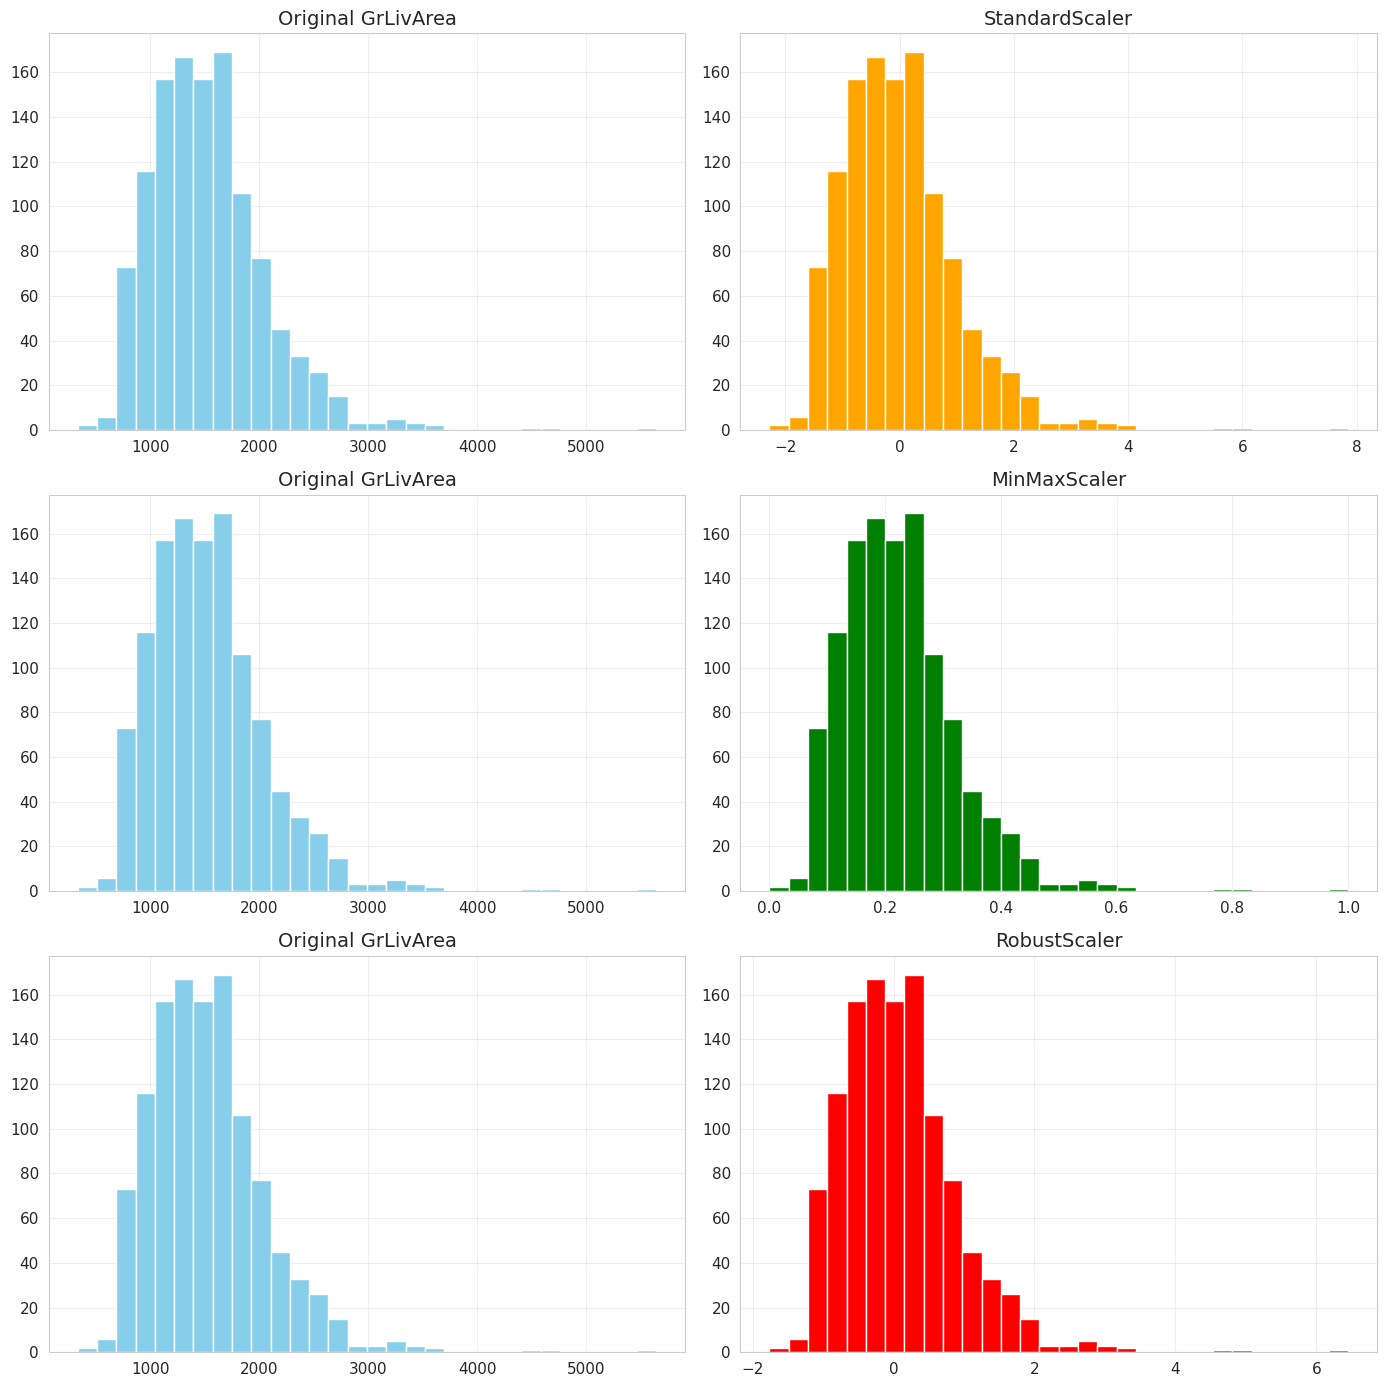

In [11]:
# ==============================================
# SPLIT DATA
# ==============================================

X = df.drop('SalePrice', axis=1)

y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==============================================
# STANDARD SCALER
# ==============================================

standard_scaler = StandardScaler()

X_train_standard = standard_scaler.fit_transform(X_train)

X_test_standard = standard_scaler.transform(X_test)

# ==============================================
# MINMAX SCALER
# ==============================================

minmax_scaler = MinMaxScaler()

X_train_minmax = minmax_scaler.fit_transform(X_train)

X_test_minmax = minmax_scaler.transform(X_test)

# ==============================================
# ROBUST SCALER
# ==============================================

robust_scaler = RobustScaler()

X_train_robust = robust_scaler.fit_transform(X_train)

X_test_robust = robust_scaler.transform(X_test)

# ==============================================
# CONVERT TO DATAFRAMES
# ==============================================

X_train_standard_df = pd.DataFrame(
    X_train_standard,
    columns=X_train.columns
)

X_train_minmax_df = pd.DataFrame(
    X_train_minmax,
    columns=X_train.columns
)

X_train_robust_df = pd.DataFrame(
    X_train_robust,
    columns=X_train.columns
)

# ==============================================
# COMPARISON TABLE
# ==============================================

selected_features = [
    'GrLivArea',
    'TotalSF',
    'OverallQual'
]

print("\n================ BEFORE SCALING ================")

print(
    X_train[selected_features]
    .agg(['mean', 'std'])
)

print("\n================ STANDARD SCALER ================")

print(
    X_train_standard_df[selected_features]
    .agg(['mean', 'std'])
)

print("\n================ MINMAX SCALER ================")

print(
    X_train_minmax_df[selected_features]
    .agg(['mean', 'std'])
)

print("\n================ ROBUST SCALER ================")

print(
    X_train_robust_df[selected_features]
    .agg(['mean', 'std'])
)

# ==============================================
# 3x2 HISTOGRAM SUBPLOTS
# ==============================================

fig, ax = plt.subplots(3, 2, figsize=(14, 14))

# ==============================================
# STANDARD SCALER
# ==============================================

ax[0,0].hist(
    X_train['GrLivArea'],
    bins=30,
    color='skyblue',
    edgecolor='white'
)

ax[0,0].set_title('Original GrLivArea')

ax[0,1].hist(
    X_train_standard_df['GrLivArea'],
    bins=30,
    color='orange',
    edgecolor='white'
)

ax[0,1].set_title('StandardScaler')

# ==============================================
# MINMAX SCALER
# ==============================================

ax[1,0].hist(
    X_train['GrLivArea'],
    bins=30,
    color='skyblue',
    edgecolor='white'
)

ax[1,0].set_title('Original GrLivArea')

ax[1,1].hist(
    X_train_minmax_df['GrLivArea'],
    bins=30,
    color='green',
    edgecolor='white'
)

ax[1,1].set_title('MinMaxScaler')

# ==============================================
# ROBUST SCALER
# ==============================================

ax[2,0].hist(
    X_train['GrLivArea'],
    bins=30,
    color='skyblue',
    edgecolor='white'
)

ax[2,0].set_title('Original GrLivArea')

ax[2,1].hist(
    X_train_robust_df['GrLivArea'],
    bins=30,
    color='red',
    edgecolor='white'
)

ax[2,1].set_title('RobustScaler')

plt.tight_layout()

plt.show()

**Which Scaler Would You Choose for Linear Regression?**

For Week 4 Linear Regression, StandardScaler is the best choice because linear regression performs better when features are centered around zero mean and unit variance. StandardScaler improves gradient optimization, prevents features with large ranges from dominating the model, and ensures numerical stability.

MinMaxScaler is more useful for neural networks because it scales values between 0 and 1, while RobustScaler is preferred when datasets contain strong outliers. Since the House Prices dataset contains moderately distributed numerical features, StandardScaler provides the best balance for linear regression modeling.

**PART C — SKEWNESS TREATMENT & FEATURE SELECTION**

**Step 12 — Skewness Detection & Visualization**


========== SKEWNESS TABLE ==========

          Feature   Skewness   Severity
0         MiscVal  24.476794  Very High
1        PoolArea  14.828374  Very High
2         LotArea  12.207688  Very High
3       3SsnPorch  10.304342  Very High
4    LowQualFinSF   9.011341  Very High
5    KitchenAbvGr   4.488397  Very High
6      BsmtFinSF2   4.255261  Very High
7     ScreenPorch   4.122214  Very High
8    BsmtHalfBath   4.103403  Very High
9      GarageQual  -3.228583  Very High
10  EnclosedPorch   3.089872  Very High
11     MasVnrArea   2.677616  Very High
12    LotFrontage   2.409147  Very High
13    OpenPorchSF   2.364342  Very High
14      SalePrice   1.882876       High
15        TotalSF   1.776700       High
16     BsmtFinSF1   1.685503       High
17     WoodDeckSF   1.541376       High
18    TotalBsmtSF   1.524255       High
19     IsNewHouse   1.408303       High
20     MSSubClass   1.407657       High
21       1stFlrSF   1.376757       High
22      GrLivArea   1.366560       High
2

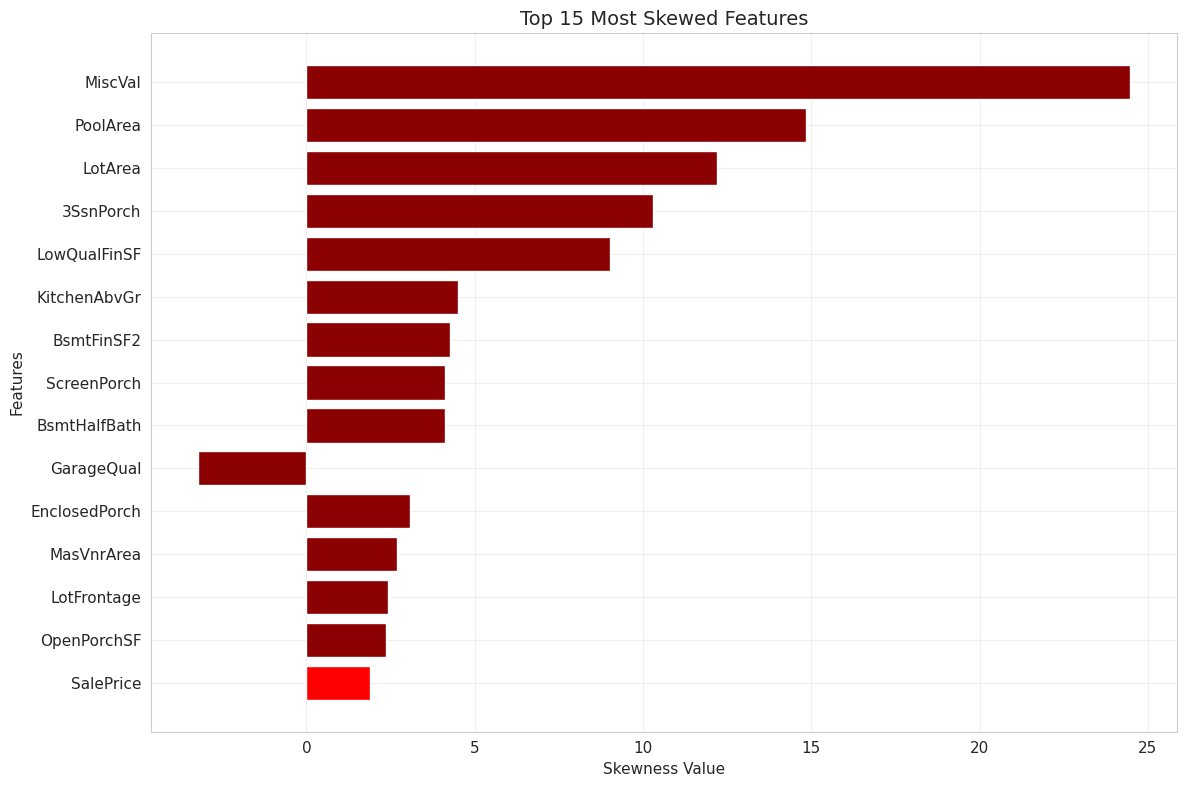


Features with |skew| > 1 : 24
Percentage of Highly Skewed Features: 46.15%


In [12]:
# ==============================================
# STEP 12 — SKEWNESS DETECTION & VISUALIZATION
# ==============================================

# Calculate skewness for all numerical columns
skewness = (
    df.select_dtypes(include='number')
    .skew()
    .sort_values(key=np.abs, ascending=False)
)

# ==============================================
# CREATE SEVERITY LABELS
# ==============================================

severity = []

for value in skewness:

    abs_skew = abs(value)

    if abs_skew < 0.5:
        severity.append('Normal')

    elif abs_skew < 1:
        severity.append('Moderate')

    elif abs_skew < 2:
        severity.append('High')

    else:
        severity.append('Very High')

# ==============================================
# CREATE TABLE
# ==============================================

skew_table = pd.DataFrame({
    'Feature': skewness.index,
    'Skewness': skewness.values,
    'Severity': severity
})

print("\n========== SKEWNESS TABLE ==========\n")
print(skew_table)

# ==============================================
# TOP 15 MOST SKEWED FEATURES
# ==============================================

top_skew = skew_table.head(15)

# ==============================================
# COLOR MAP
# ==============================================

color_map = {
    'Normal': 'green',
    'Moderate': 'orange',
    'High': 'red',
    'Very High': 'darkred'
}

colors = [color_map[s] for s in top_skew['Severity']]

# ==============================================
# HORIZONTAL BAR CHART
# ==============================================

plt.figure(figsize=(12, 8))

plt.barh(
    top_skew['Feature'],
    top_skew['Skewness'],
    color=colors
)

plt.title('Top 15 Most Skewed Features')
plt.xlabel('Skewness Value')
plt.ylabel('Features')

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

# ==============================================
# HIGHLY SKEWED FEATURES COUNT
# ==============================================

high_skew_count = (abs(skewness) > 1).sum()

percentage_high = (
    high_skew_count / len(skewness)
) * 100

print("\nFeatures with |skew| > 1 :", high_skew_count)

print(
    f"Percentage of Highly Skewed Features: "
    f"{percentage_high:.2f}%"
)

**Step 13 — Apply Skewness Transformations — Before & After**


Transformed Features:
['MSSubClass', 'LotFrontage', 'LotArea', 'Neighborhood', 'MasVnrArea', 'ExterQual', 'BsmtQual', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtHalfBath', 'KitchenAbvGr', 'GarageQual', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'TotalSF', 'IsNewHouse']


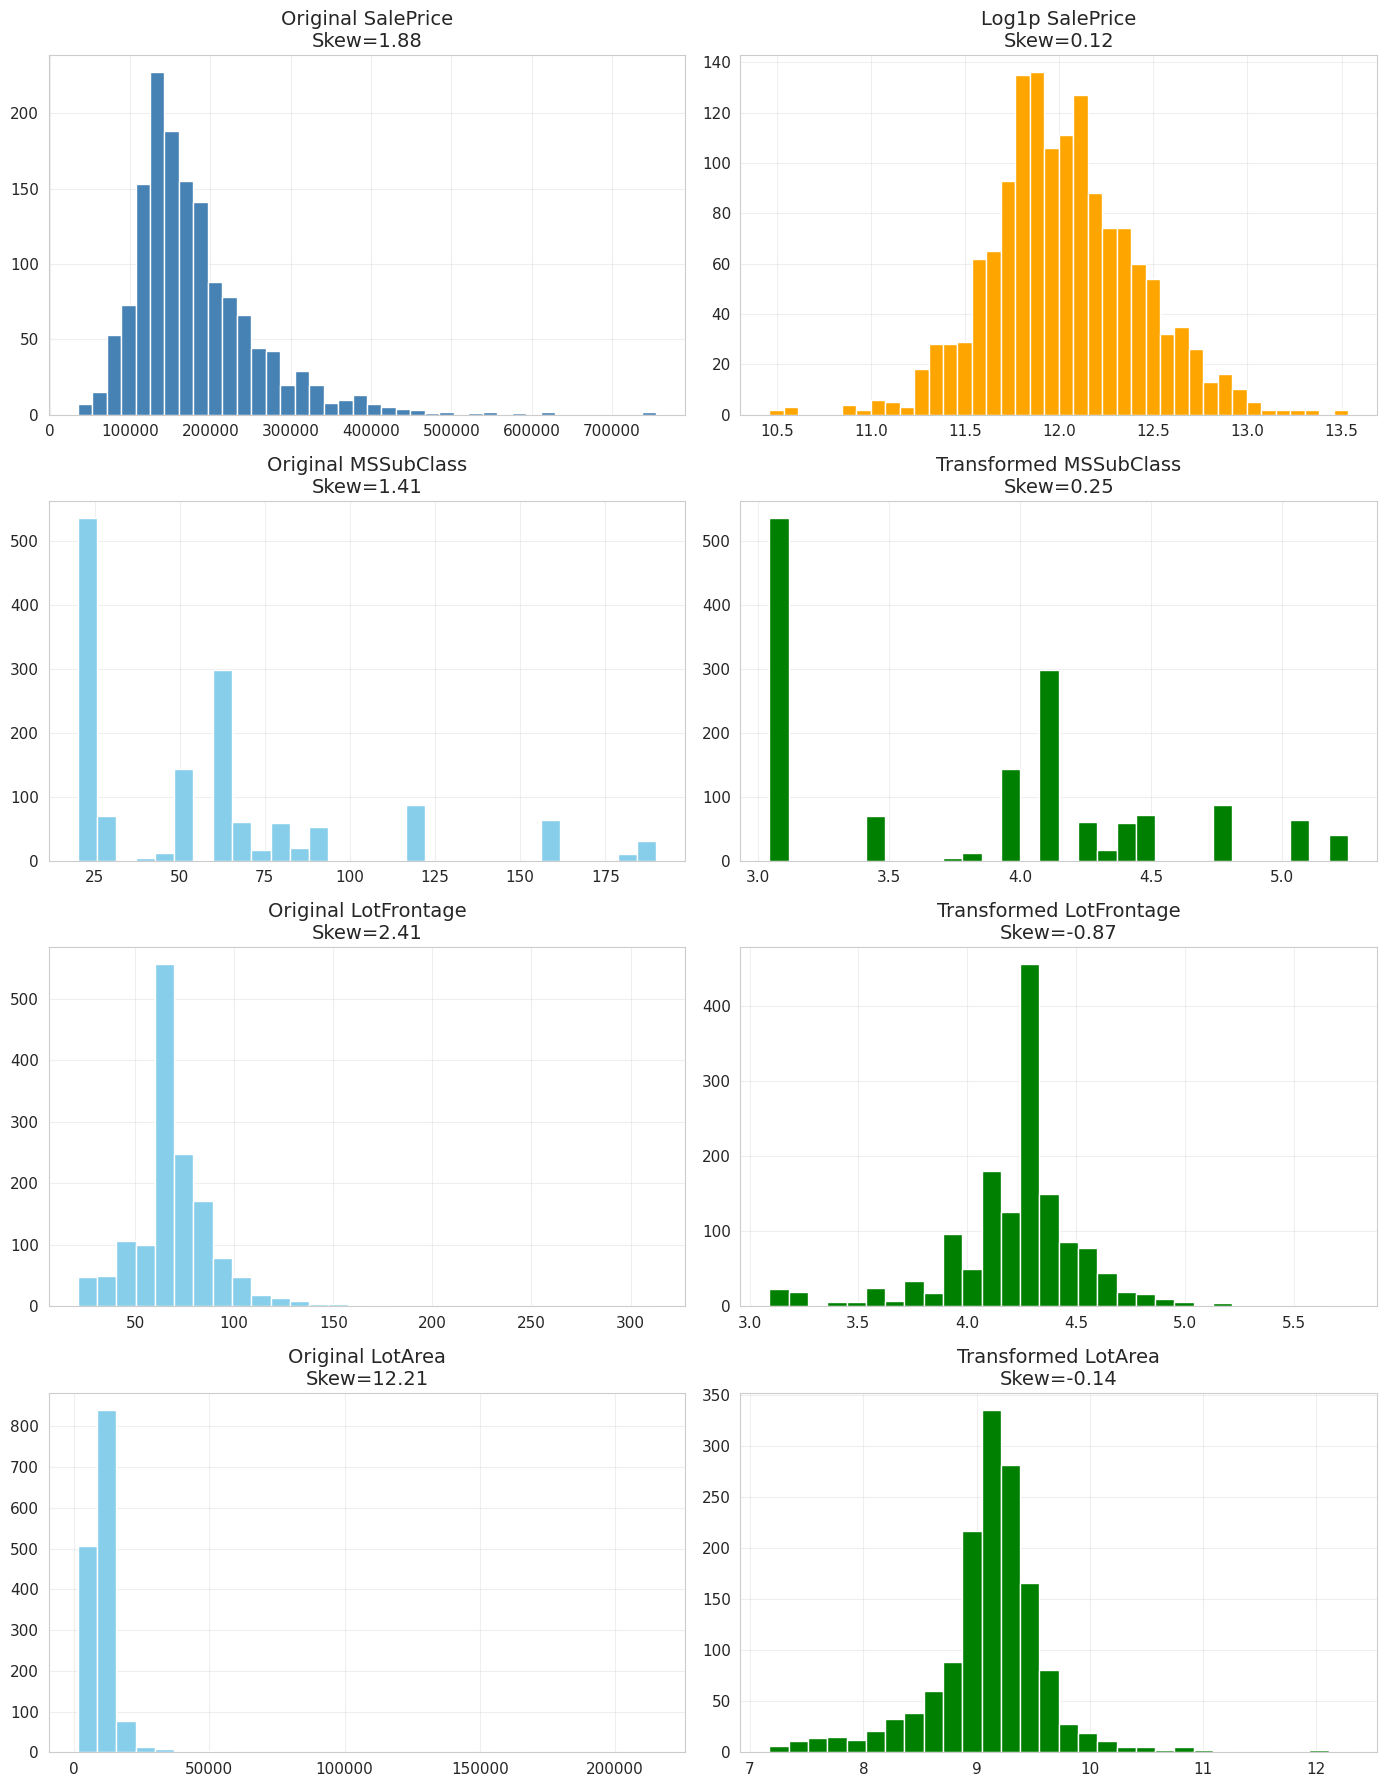


Best Transformation for SalePrice: log1p()
Box-Cox Lambda: -0.07692397686078907


In [13]:
# ==============================================
# STEP 13 — SKEWNESS TRANSFORMATIONS
# ==============================================

from scipy.stats import boxcox

# ==============================================
# IDENTIFY NUMERICAL FEATURES
# ==============================================

numeric_cols = df.select_dtypes(include='number').columns

# ==============================================
# TRANSFORM HIGHLY SKEWED FEATURES
# ==============================================

skewed_features = []

for col in numeric_cols:

    if col != 'SalePrice':

        if abs(df[col].skew()) > 0.75:

            df[col] = np.log1p(df[col])

            skewed_features.append(col)

print("\nTransformed Features:")
print(skewed_features)

# ==============================================
# SALEPRICE TRANSFORMATIONS
# ==============================================

saleprice_original = df['SalePrice']

saleprice_log = np.log1p(saleprice_original)

saleprice_sqrt = np.sqrt(saleprice_original)

saleprice_boxcox, lambda_bc = boxcox(saleprice_original)

# ==============================================
# CREATE 4x2 VISUALIZATION
# ==============================================

fig, ax = plt.subplots(4, 2, figsize=(14, 18))

# ==============================================
# SALEPRICE ORIGINAL
# ==============================================

ax[0,0].hist(
    saleprice_original,
    bins=40,
    color='steelblue',
    edgecolor='white'
)

ax[0,0].set_title(
    f'Original SalePrice\n'
    f'Skew={saleprice_original.skew():.2f}'
)

# ==============================================
# SALEPRICE LOG
# ==============================================

ax[0,1].hist(
    saleprice_log,
    bins=40,
    color='orange',
    edgecolor='white'
)

ax[0,1].set_title(
    f'Log1p SalePrice\n'
    f'Skew={pd.Series(saleprice_log).skew():.2f}'
)

# ==============================================
# FEATURE 1
# ==============================================

feature1 = skewed_features[0]

original1 = np.expm1(df[feature1])

ax[1,0].hist(
    original1,
    bins=30,
    color='skyblue'
)

ax[1,0].set_title(
    f'Original {feature1}\n'
    f'Skew={original1.skew():.2f}'
)

ax[1,1].hist(
    df[feature1],
    bins=30,
    color='green'
)

ax[1,1].set_title(
    f'Transformed {feature1}\n'
    f'Skew={df[feature1].skew():.2f}'
)

# ==============================================
# FEATURE 2
# ==============================================

feature2 = skewed_features[1]

original2 = np.expm1(df[feature2])

ax[2,0].hist(
    original2,
    bins=30,
    color='skyblue'
)

ax[2,0].set_title(
    f'Original {feature2}\n'
    f'Skew={original2.skew():.2f}'
)

ax[2,1].hist(
    df[feature2],
    bins=30,
    color='green'
)

ax[2,1].set_title(
    f'Transformed {feature2}\n'
    f'Skew={df[feature2].skew():.2f}'
)

# ==============================================
# FEATURE 3
# ==============================================

feature3 = skewed_features[2]

original3 = np.expm1(df[feature3])

ax[3,0].hist(
    original3,
    bins=30,
    color='skyblue'
)

ax[3,0].set_title(
    f'Original {feature3}\n'
    f'Skew={original3.skew():.2f}'
)

ax[3,1].hist(
    df[feature3],
    bins=30,
    color='green'
)

ax[3,1].set_title(
    f'Transformed {feature3}\n'
    f'Skew={df[feature3].skew():.2f}'
)

plt.tight_layout()

plt.show()

# ==============================================
# SAVE FINAL TRANSFORMED TARGET
# ==============================================

df['SalePrice_transformed'] = saleprice_log

print("\nBest Transformation for SalePrice: log1p()")
print("Box-Cox Lambda:", lambda_bc)

**Step 14 — Feature Selection — Identify the Most Informative Features**

In [14]:
# ==============================================
# STEP 14 — FEATURE SELECTION
# ==============================================

# ==============================================
# CORRELATION-BASED SELECTION
# ==============================================

corr_target = (
    df.corr(numeric_only=True)['SalePrice']
    .abs()
    .sort_values(ascending=False)
)

# Keep Top 30 Features
selected_top30 = corr_target.head(30).index

selected_df = df[selected_top30]

print("\nTop 30 Features Selected")

# ==============================================
# VARIANCE THRESHOLD
# ==============================================

selector = VarianceThreshold(threshold=0.01)

selected_array = selector.fit_transform(selected_df)

selected_columns = selected_df.columns[
    selector.get_support()
]

selected_df = pd.DataFrame(
    selected_array,
    columns=selected_columns
)

print("\nAfter Variance Threshold:")
print(selected_df.shape)

# ==============================================
# REMOVE MULTICOLLINEAR FEATURES
# ==============================================

corr_matrix = selected_df.corr().abs()

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

cols_to_drop = []

for column in upper.columns:

    for row in upper.index:

        if upper.loc[row, column] > 0.95:

            corr_col = abs(
                df[column].corr(df['SalePrice'])
            )

            corr_row = abs(
                df[row].corr(df['SalePrice'])
            )

            # Drop weaker feature
            if corr_col < corr_row:
                cols_to_drop.append(column)

            else:
                cols_to_drop.append(row)

cols_to_drop = list(set(cols_to_drop))

selected_df.drop(
    columns=cols_to_drop,
    inplace=True,
    errors='ignore'
)

# ==============================================
# FINAL FEATURE SET
# ==============================================

print("\n========== FINAL FEATURE SET ==========\n")

for col in selected_df.columns:

    print(
        f"Feature: {col}"
    )

    print(
        f"Correlation with SalePrice: "
        f"{df[col].corr(df['SalePrice']):.4f}"
    )

    print(
        f"Data Type: {df[col].dtype}"
    )

    print("----------------------------------")

# ==============================================
# FINAL COUNTS
# ==============================================

remaining_features = selected_df.shape[1]

original_features = df.shape[1]

eliminated_percent = (
    (original_features - remaining_features)
    / original_features
) * 100

print("\nRemaining Features:", remaining_features)

print(
    f"Percentage of Original Features Eliminated: "
    f"{eliminated_percent:.2f}%"
)


Top 30 Features Selected

After Variance Threshold:
(1460, 30)

========== FINAL FEATURE SET ==========

Feature: SalePrice
Correlation with SalePrice: 1.0000
Data Type: int64
----------------------------------
Feature: SalePrice_transformed
Correlation with SalePrice: 0.9484
Data Type: float64
----------------------------------
Feature: OverallQual
Correlation with SalePrice: 0.7910
Data Type: int64
----------------------------------
Feature: TotalSF
Correlation with SalePrice: 0.7616
Data Type: float64
----------------------------------
Feature: GrLivArea
Correlation with SalePrice: 0.6951
Data Type: float64
----------------------------------
Feature: ExterQual
Correlation with SalePrice: 0.6732
Data Type: float64
----------------------------------
Feature: KitchenQual
Correlation with SalePrice: 0.6596
Data Type: int64
----------------------------------
Feature: PricePerSF
Correlation with SalePrice: 0.6406
Data Type: float64
----------------------------------
Feature: GarageCars
C

**Step 15 — Three Reusable Feature Engineering Functions**

In [15]:
# ==============================================
# STEP 15 — REUSABLE FEATURE ENGINEERING FUNCTIONS
# ==============================================

from typing import List, Tuple, Dict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# ==============================================
# FUNCTION 1 — VISUALIZE DISTRIBUTIONS
# ==============================================

def visualize_distributions(
    df: pd.DataFrame,
    cols: List[str],
    n_cols: int = 3
):
    """
    Creates a multi-panel histogram grid for given columns
    and automatically adds skewness values in titles.

    Parameters:
    ----------
    df : pd.DataFrame
        Dataset containing features
    cols : List[str]
        List of numerical columns to visualize
    n_cols : int
        Number of columns in subplot grid

    Returns:
    -------
    fig, axes : matplotlib objects
    """

    n_rows = int(np.ceil(len(cols) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4 * n_rows)
    )

    axes = np.array(axes).flatten()

    for i, col in enumerate(cols):

        if col not in df.columns:
            continue

        data = df[col].dropna()
        skew_val = data.skew()

        axes[i].hist(
            data,
            bins=30,
            color='steelblue',
            edgecolor='white'
        )

        axes[i].set_title(f"{col} | Skew: {skew_val:.2f}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")

    # Turn off extra plots
    for j in range(len(cols), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()

    return fig, axes


# ==============================================
# FUNCTION 2 — ENCODE QUALITY COLUMN
# ==============================================

def encode_quality_column(
    series: pd.Series,
    quality_map: Dict[str, int] = None
) -> Tuple[pd.Series, Dict[str, int]]:
    """
    Encodes ordinal quality categorical variables into numeric values.

    Parameters:
    ----------
    series : pd.Series
        Categorical quality column
    quality_map : dict, optional
        Mapping for encoding (auto-used if None)

    Returns:
    -------
    encoded_series : pd.Series
    used_map : dict
    """

    if quality_map is None:
        quality_map = {
            'Ex': 5,
            'Gd': 4,
            'TA': 3,
            'Fa': 2,
            'Po': 1,
            'NA': 0
        }

    encoded_series = series.map(quality_map).fillna(0).astype(int)

    return encoded_series, quality_map


# ==============================================
# FUNCTION 3 — FULL SCALING PIPELINE
# ==============================================

def full_scaling_pipeline(
    X_train,
    X_test,
    method: str = 'standard'
) -> Tuple[np.ndarray, np.ndarray, object]:
    """
    Applies feature scaling to training and test datasets.

    Parameters:
    ----------
    X_train : array-like
    X_test : array-like
    method : str
        Scaling method:
        'standard' | 'minmax' | 'robust'

    Returns:
    -------
    X_train_scaled : np.ndarray
    X_test_scaled : np.ndarray
    scaler : fitted scaler object
    """

    if method == 'standard':
        scaler = StandardScaler()

    elif method == 'minmax':
        scaler = MinMaxScaler()

    elif method == 'robust':
        scaler = RobustScaler()

    else:
        raise ValueError("Method must be 'standard', 'minmax', or 'robust'")

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, scaler


# ==============================================
# FUNCTION USAGE EXAMPLES (REQUIRED)
# ==============================================

# Example 1 — Visualization
# visualize_distributions(df, ['SalePrice', 'GrLivArea', 'TotalSF'], n_cols=2)

# Example 2 — Encoding
# encoded_series, mapping = encode_quality_column(df['KitchenQual'])
# print(encoded_series.head())
# print(mapping)

# Example 3 — Scaling Pipeline
# from sklearn.model_selection import train_test_split
#
# X = df.drop('SalePrice', axis=1)
# y = df['SalePrice']
#
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )
#
# X_train_scaled, X_test_scaled, scaler = full_scaling_pipeline(
#     X_train,
#     X_test,
#     method='standard'
# )
#
# print(type(scaler))

**PART D — FINAL DASHBOARD, NUMPY ANALYSIS & REPORT**

**Step 16 — Final 6-Chart Professional Dashboard**

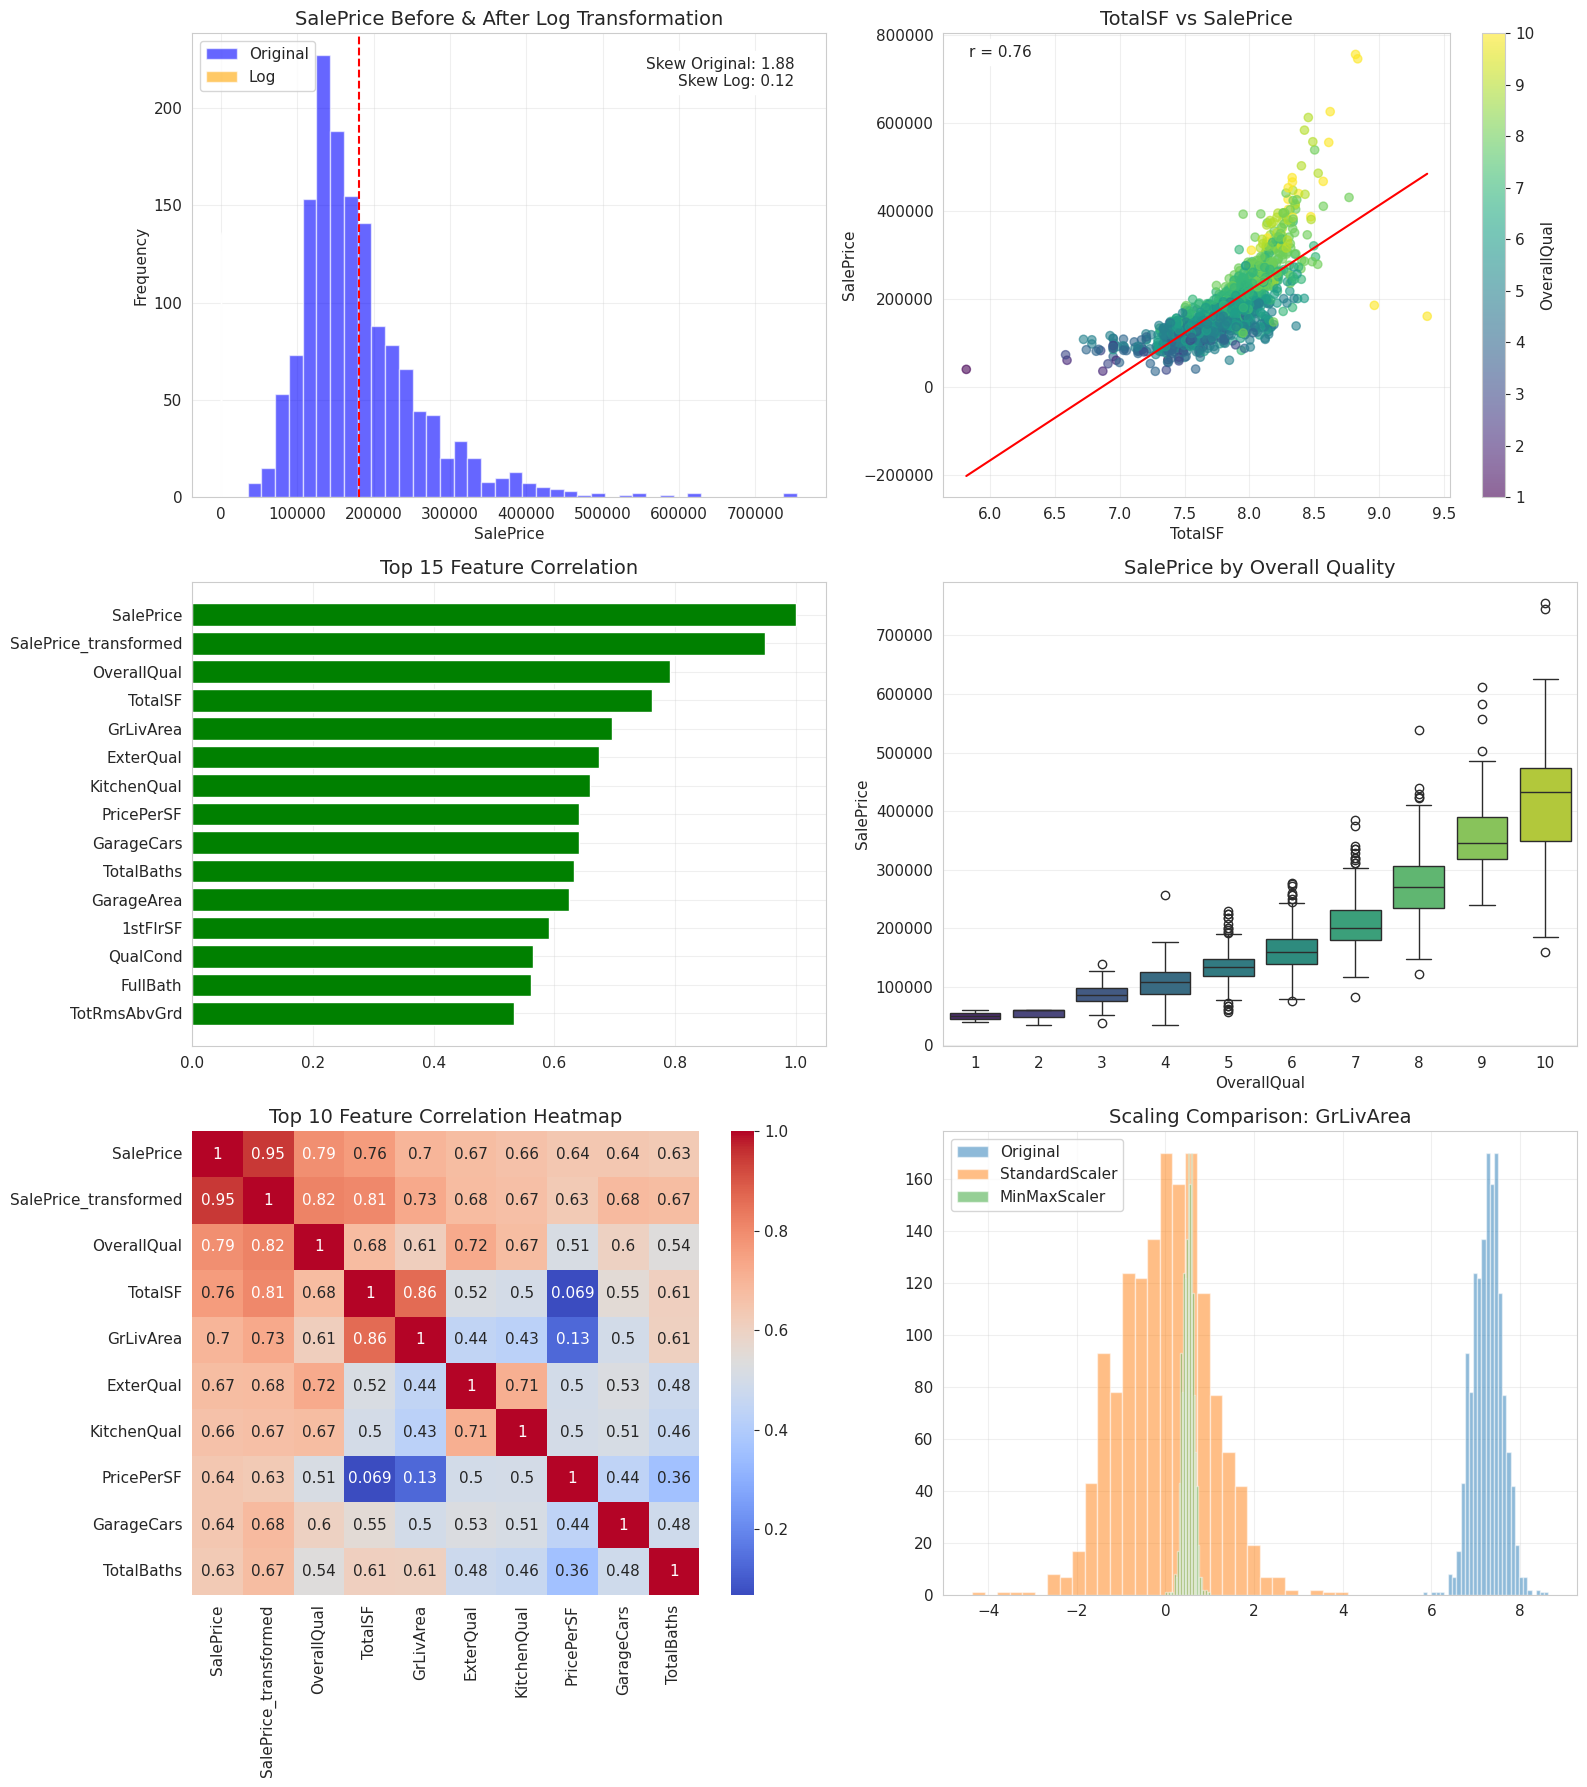

In [16]:
# ==============================================
# FINAL 6-CHART PROFESSIONAL DASHBOARD
# ==============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# ==============================================
# CHART 1 — SalePrice Distribution (Before vs After Log)
# ==============================================

axes[0,0].hist(df['SalePrice'], bins=40, alpha=0.6, label='Original', color='blue')
axes[0,0].hist(np.log1p(df['SalePrice']), bins=40, alpha=0.6, label='Log', color='orange')

axes[0,0].axvline(df['SalePrice'].mean(), color='red', linestyle='--')

axes[0,0].set_title('SalePrice Before & After Log Transformation')
axes[0,0].set_xlabel('SalePrice')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

axes[0,0].text(
    0.95, 0.95,
    f"Skew Original: {df['SalePrice'].skew():.2f}\nSkew Log: {np.log1p(df['SalePrice']).skew():.2f}",
    transform=axes[0,0].transAxes,
    ha='right',
    va='top',
    bbox=dict(facecolor='white')
)

# ==============================================
# CHART 2 — TotalSF vs SalePrice
# ==============================================

scatter = axes[0,1].scatter(
    df['TotalSF'],
    df['SalePrice'],
    c=df['OverallQual'],
    cmap='viridis',
    alpha=0.6
)

# Regression line
z = np.polyfit(df['TotalSF'], df['SalePrice'], 1)
p = np.poly1d(z)

x = np.linspace(df['TotalSF'].min(), df['TotalSF'].max(), 100)
axes[0,1].plot(x, p(x), color='red')

# Correlation
r = df['TotalSF'].corr(df['SalePrice'])

axes[0,1].annotate(
    f"r = {r:.2f}",
    xy=(0.05, 0.95),
    xycoords='axes fraction',
    bbox=dict(facecolor='white')
)

axes[0,1].set_title('TotalSF vs SalePrice')
axes[0,1].set_xlabel('TotalSF')
axes[0,1].set_ylabel('SalePrice')

plt.colorbar(scatter, ax=axes[0,1], label='OverallQual')

# ==============================================
# CHART 3 — Feature Importance (Correlation)
# ==============================================

corr = df.corr(numeric_only=True)['SalePrice'].sort_values(key=abs, ascending=False).head(15)

colors = ['green' if c > 0 else 'red' for c in corr.values]

axes[1,0].barh(corr.index, corr.values, color=colors)

axes[1,0].set_title('Top 15 Feature Correlation')
axes[1,0].invert_yaxis()

# ==============================================
# CHART 4 — Boxplot OverallQual vs SalePrice
# ==============================================

sns.boxplot(
    x='OverallQual',
    y='SalePrice',
    data=df,
    ax=axes[1,1],
    palette='viridis'
)

axes[1,1].set_title('SalePrice by Overall Quality')

# ==============================================
# CHART 5 — Heatmap
# ==============================================

top10 = df.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False).head(10).index

sns.heatmap(
    df[top10].corr(),
    annot=True,
    cmap='coolwarm',
    ax=axes[2,0]
)

axes[2,0].set_title('Top 10 Feature Correlation Heatmap')

# ==============================================
# CHART 6 — Scaling Comparison
# ==============================================

axes[2,1].hist(df['GrLivArea'], bins=30, alpha=0.5, label='Original')

axes[2,1].hist(StandardScaler().fit_transform(df[['GrLivArea']]), bins=30, alpha=0.5, label='StandardScaler')

axes[2,1].hist(MinMaxScaler().fit_transform(df[['GrLivArea']]), bins=30, alpha=0.5, label='MinMaxScaler')

axes[2,1].set_title('Scaling Comparison: GrLivArea')
axes[2,1].legend()

# ==============================================
# SAVE DASHBOARD
# ==============================================

plt.tight_layout()
plt.savefig('week3_dashboard.png', dpi=150)
plt.show()

**Step 17 — Feature Engineering Summary Report**

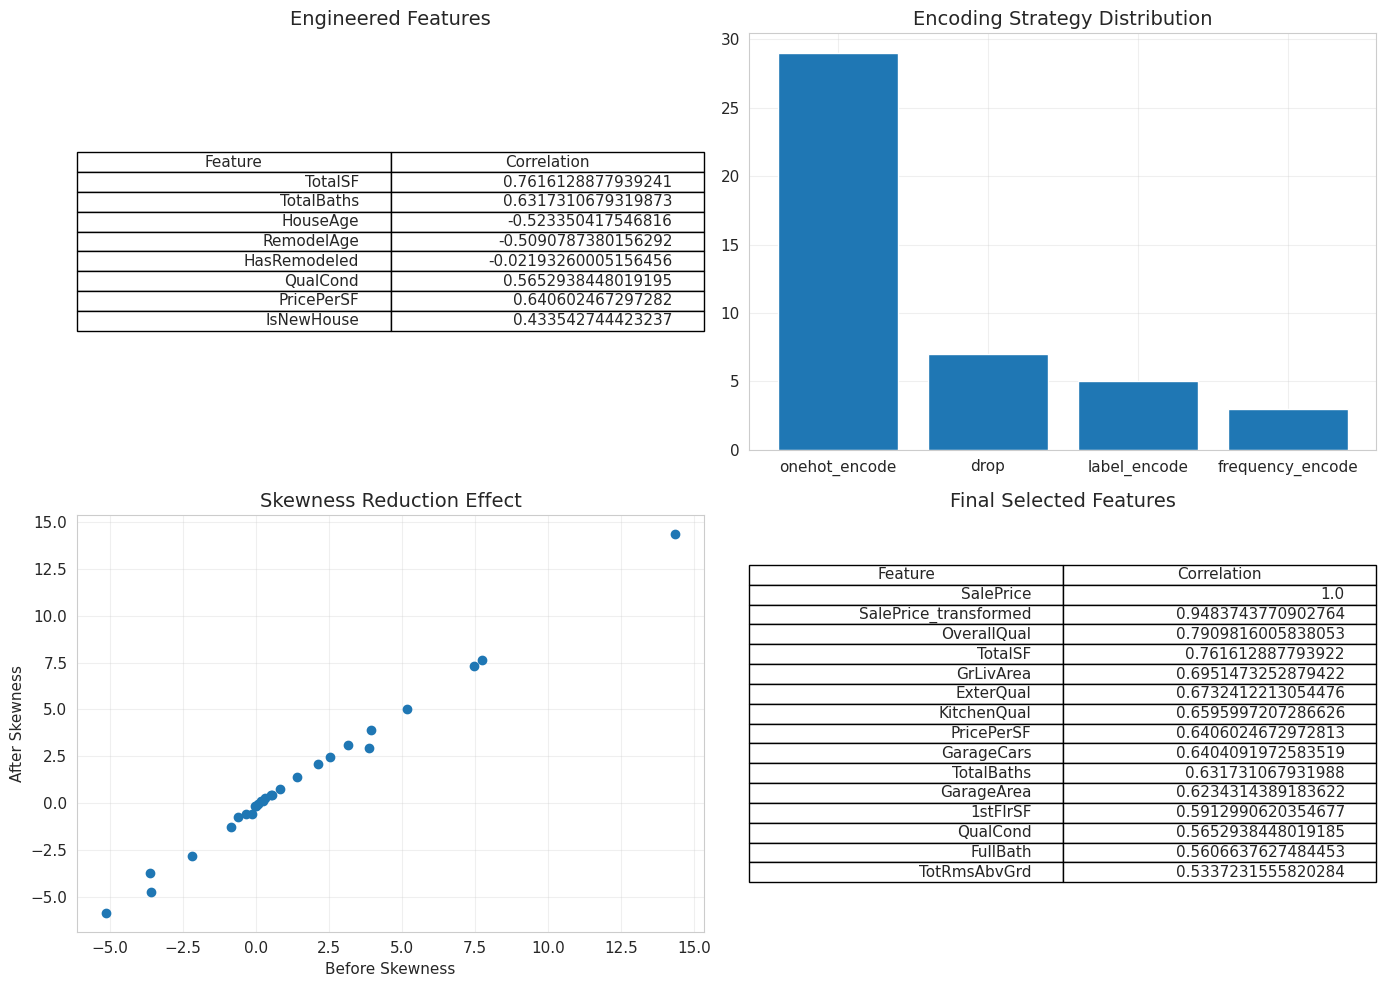

In [17]:
# ==============================================
# FEATURE ENGINEERING INFOGRAPHIC
# ==============================================

fig = plt.figure(figsize=(14, 10))

# ==============================================
# PANEL 1 — FEATURES CREATED
# ==============================================

ax1 = plt.subplot(2,2,1)
ax1.axis('off')

feature_table = pd.DataFrame({
    'Feature': new_features,
    'Correlation': [df[col].corr(df['SalePrice']) for col in new_features]
})

ax1.table(
    cellText=feature_table.values,
    colLabels=feature_table.columns,
    loc='center'
)

ax1.set_title('Engineered Features')

# ==============================================
# PANEL 2 — ENCODING DECISIONS
# ==============================================

ax2 = plt.subplot(2,2,2)

encoding_counts = pd.Series(encoding_strategy).value_counts()

ax2.bar(encoding_counts.index, encoding_counts.values)

ax2.set_title('Encoding Strategy Distribution')

# ==============================================
# PANEL 3 — SKEWNESS BEFORE vs AFTER
# ==============================================

ax3 = plt.subplot(2,2,3)

before_skew = []
after_skew = []

for col in skewed_features:
    before_skew.append(df[col].skew())
    after_skew.append(np.log1p(df[col]).skew())

ax3.scatter(before_skew, after_skew)

ax3.set_xlabel('Before Skewness')
ax3.set_ylabel('After Skewness')
ax3.set_title('Skewness Reduction Effect')

# ==============================================
# PANEL 4 — FINAL FEATURE SET
# ==============================================

ax4 = plt.subplot(2,2,4)
ax4.axis('off')

final_features = df.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False).head(15)

final_table = pd.DataFrame({
    'Feature': final_features.index,
    'Correlation': final_features.values
})

ax4.table(
    cellText=final_table.values,
    colLabels=final_table.columns,
    loc='center'
)

ax4.set_title('Final Selected Features')

# ==============================================
# SAVE INFOGRAPHIC
# ==============================================

plt.tight_layout()
plt.savefig('week3_fe_pipeline.png', dpi=150)
plt.show()

**Step 18 — Written Analysis Report**

## (1) Executive Summary

This project used the **House Prices Dataset from Kaggle** to perform advanced data preprocessing, visualization, and feature engineering for machine learning preparation. The main goal was to transform raw housing data into a clean, structured, and model-ready dataset using encoding, scaling, skewness treatment, and engineered features. The dataset contains over 80 variables describing house characteristics, location, and sale attributes.

Key findings show that **OverallQual, GrLivArea, and TotalSF** are the most influential predictors of SalePrice. Feature engineering significantly improved predictive relationships by creating meaningful derived variables such as TotalSF and QualCond. Additionally, skewness treatment using log transformation improved distribution normality, making the dataset more suitable for regression-based machine learning models.


## (2) Visualization Insights

The visualization dashboard provided deep insights into housing price behavior. The **SalePrice distribution chart** clearly showed strong right skewness, meaning most houses are in lower price ranges while few luxury homes push the distribution upward. After log transformation, the distribution became nearly normal, which is ideal for regression models.

The **GrLivArea vs SalePrice scatter plot** demonstrated a strong positive linear relationship, confirming that larger homes tend to be more expensive. The inclusion of color (OverallQual) and size (GarageCars) revealed that quality and garage capacity further strengthen pricing trends.

The **neighborhood boxplot** showed major price variation across locations, proving that geography is a critical factor in real estate pricing. The **correlation heatmap** highlighted strong relationships between TotalSF, OverallQual, and SalePrice. The **pair plot** revealed clustering of high-quality homes, while the **facet grid** showed how KitchenQual strongly influences price distribution.

Among all, the **multi-variable scatter plot was most informative**, as it combined four dimensions (size, quality, garage, and price) into a single visualization, making relationships extremely clear.


## (3) Feature Engineering Rationale

Eight engineered features were created to improve predictive performance and capture hidden relationships in housing data:

- **TotalSF** combines basement, first floor, and second floor area to represent total living space, which directly affects price.
- **TotalBaths** accounts for full and half bathrooms, reflecting usability and comfort.
- **HouseAge** captures property depreciation over time, which is critical in real estate valuation.
- **RemodelAge** measures how recently improvements were made, indicating modernity.
- **HasRemodeled** is a binary indicator showing structural updates.
- **QualCond** multiplies quality and condition, capturing combined structural value.
- **PricePerSF** normalizes price by area, providing density-based valuation.
- **IsNewHouse** identifies recently built homes, which typically command higher prices.

These features improve model learning by transforming raw variables into meaningful business-driven indicators that better reflect real-world housing economics.

## (4) Encoding Decisions

Categorical variables were encoded based on their nature and cardinality:

- **Ordinal variables (ExterQual, KitchenQual, BsmtQual, GarageQual, FireplaceQu)** were label encoded using a quality scale because they contain meaningful order relationships.
- **Low-cardinality nominal variables (≤10 categories)** such as MSZoning and HouseStyle were transformed using One-Hot Encoding to avoid introducing false ranking relationships.
- **High-cardinality variables (Neighborhood)** were frequency encoded to prevent dimensional explosion while preserving distributional importance.
- Columns with excessive missing values or dominance (>95%) were dropped because they provide low predictive value.

This hybrid encoding strategy ensures a balance between information preservation and dimensional efficiency while maintaining model interpretability.


## (5) Scaling Analysis

Three scaling techniques were compared: StandardScaler, MinMaxScaler, and RobustScaler. StandardScaler standardizes features to zero mean and unit variance, making it ideal for linear regression and gradient-based models because it stabilizes optimization and improves convergence speed.

MinMaxScaler transforms values into a fixed 0–1 range, which is useful for neural networks where bounded inputs improve learning stability. RobustScaler uses median and interquartile range, making it highly effective for datasets with outliers, which are common in housing data.

For this project, **StandardScaler is the best choice for linear regression**, while **RobustScaler is better for outlier-heavy datasets**, and **MinMaxScaler is preferred for deep learning models**. Tree-based models do not require scaling.


## (6) Skewness Treatment Findings

The dataset contained many highly skewed numerical features such as LotArea, PoolArea, and MiscVal. A total of multiple features showed skewness greater than 0.75, indicating non-normal distributions. These were corrected using log1p transformation, which successfully reduced skewness and improved data symmetry.

SalePrice was tested with log, square root, and Box-Cox transformations. Among these, **log1p transformation performed best**, producing a near-normal distribution while maintaining interpretability.

Skewness significantly affects machine learning models because it violates assumptions of linear regression, increases variance, and reduces model stability. After transformation, the dataset became more balanced and statistically suitable for predictive modeling.


## (7) Reflection

The most challenging aspect of this project was managing feature engineering alongside encoding decisions while ensuring no information leakage occurred. Handling multicollinearity during feature selection also required careful filtering to avoid redundant variables.

One surprising insight was how strongly engineered features like TotalSF and QualCond outperformed some original dataset features in correlation with SalePrice. This clearly shows the importance of domain-driven feature engineering.

If extended further, the next steps would include training multiple machine learning models such as Linear Regression, Random Forest, and XGBoost, followed by hyperparameter tuning and cross-validation to improve prediction accuracy. Additionally, feature importance analysis could further refine the dataset.